
Things I want to do with this code
- create CA area of interest (CA + surrounding states)
- create CA power grid (hopefully doing some local validation tests on the HIFLD grid data) 
    - somehow widen that representation to include capacity of the elements (transmission lines and substations)
    - some way of revealing cascading dynamics (and identifying on the map of outages)
    - incorporate whatever data can be found on Public Safety Power Shutoffs (PSPS) and identify on the movie
- get the data that Yuliya (terrestrial wx) and Nick (wildfire) shared
    - using what we have learned to identify the critical variables/approaches to encoding each of these hazards from a power grid impact perspective
- build a chunked approach to data ingest: given a user-specified timespan, get the data from all hazards into a grid
- get the eagle-I data on outages and make a movie for all of 2024 with some indication of critical times of outages (time series + county-level indication)
- calculate power grid impacts/stresses based on hazards, interactions, preconditioning, topology, cascading conditions
- relating the information to important information for power grid reliability and resilience practitioners





In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os, re
import requests
import json
from datetime import datetime, time


from shapely.geometry import Point, Polygon, MultiPolygon, LineString, shape

from typing import Literal

import xarray as xr

import matplotlib.pyplot as plt

import rioxarray

import networkx as nx

# Define Functions

In [3]:
def get_start_end_coordinates(geom):
    start_points = []
    end_points = []
    for line in geom.geoms:  # Access individual LineString geometries within the MultiLineString
        start_points.append(line.coords[0])   # Get the first coordinate of each LineString
        end_points.append(line.coords[-1])    # Get the last coordinate of each LineString
    return start_points, end_points




# Define constants

In [4]:
crs_analysis = "EPSG:4326" # WGS84 Latitude/Longitude

# Get power grid as our background network

In [5]:
file_path_powergrid = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/physical_grid_data/U.S._Electric_Power_Transmission_Lines.geojson"
gdf_powergrid = gpd.read_file(file_path_powergrid)



# Convert timeframes to folium-friendly types
gdf_powergrid['SOURCEDATE'] = pd.to_datetime(gdf_powergrid['SOURCEDATE']).dt.strftime('%Y-%m-%dT%H:%M:%S')
gdf_powergrid['VAL_DATE'] = pd.to_datetime(gdf_powergrid['VAL_DATE']).dt.strftime('%Y-%m-%dT%H:%M:%S')


# Drop columns with 'NOT AVAILABLE' as substation value
# gdf[ (gdf['SUB_1']=='NOT AVAILABLE') | (gdf['SUB_2']=='NOT AVAILABLE')]
condition = ( (gdf_powergrid['SUB_1']=='NOT AVAILABLE') | (gdf_powergrid['SUB_2']=='NOT AVAILABLE') )
gdf_powergrid = gdf_powergrid[~condition]
# gdf

# Drop columns with 'NONE' as substation value
condition = ( (gdf_powergrid['SUB_1']=='NONE') | (gdf_powergrid['SUB_2']=='NONE') )
gdf_powergrid = gdf_powergrid[~condition]
gdf_powergrid



,FID,OBJECTID,ID,TYPE,STATUS,NAICS_CODE,NAICS_DESC,SOURCE,SOURCEDATE,VAL_METHOD,...,OWNER,VOLTAGE,VOLT_CLASS,INFERRED,SUB_1,SUB_2,SHAPE__Len,GlobalID,SHAPE_Length,geometry
0,1,501,135919,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 860",2014-08-04T00:00:00,IMAGERY,...,NOT AVAILABLE,69.0,UNDER 100,Y,UNKNOWN115865,TAP142941,29.188701,{73B386A9-AE19-4673-AE34-A87E1E490FE1},0.000227,"MULTILINESTRING ((-92.27198 30.22732, -92.2720..."
1,2,502,141425,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861",2014-04-07T00:00:00,IMAGERY,...,ALABAMA POWER CO,115.0,100-161,Y,UNKNOWN109093,TAP142857,74.705018,{9EA82903-87B1-4BB6-84B5-9B372F739699},0.000583,"MULTILINESTRING ((-87.82312 30.60263, -87.8232..."
2,3,503,141426,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,IMAGERY,2014-07-15T00:00:00,IMAGERY,...,"DUKE ENERGY CAROLINAS, LLC",100.0,100-161,Y,UNKNOWN115051,TAP154872,70.223774,{6008C7EC-8421-487A-9CB1-22801412BEB7},0.000591,"MULTILINESTRING ((-81.85754 35.03416, -81.8580..."
3,4,504,141429,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap, http://www.oatioasis.c...",2014-07-08T00:00:00,IMAGERY,...,TENNESSEE VALLEY AUTHORITY,161.0,100-161,N,FORT PAYNE PRIMARY,TAP152965,12929.295887,{1678DB1B-7C05-4927-A0FA-7E9011CABC1A},0.109258,"MULTILINESTRING ((-85.68872 34.47813, -85.6893..."
4,5,505,141422,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, EIA 861, EIA 860",2015-05-28T00:00:00,IMAGERY,...,COMMONWEALTH EDISON CO,138.0,100-161,Y,UNKNOWN121903,TAP137923,1737.440378,{DE001834-13ED-4FE4-96CC-789BDF3B01F9},0.012158,"MULTILINESTRING ((-87.96213 42.03757, -87.9625..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93042,93043,93043,315082,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,Western Electricity Coordinating Council https...,2017-01-01T00:00:00,IMAGERY/OTHER,...,NOT AVAILABLE,230.0,220-287,N,TAP317033,LONE BUTTE,3437.236752,{99755F96-1FD1-403B-9A00-7351EF073AA3},0.025857,"MULTILINESTRING ((-111.99586 33.22352, -111.99..."
93043,93044,93044,315083,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2019-11-23T00:00:00,IMAGERY,...,"ENTERGY TEXAS, INC.",138.0,100-161,Y,TAP316626,TAP316629,3287.127256,{4DD4F2D4-470F-4C1F-9948-C28B485F733D},0.028136,"MULTILINESTRING ((-94.06849 30.05597, -94.0669..."
93044,93045,93045,315084,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2019-11-23T00:00:00,IMAGERY,...,"ENTERGY TEXAS, INC.",138.0,100-161,Y,TAP316627,TAP316630,103.168311,{1FFEACEF-46E0-49EA-9367-CBD918C10A35},0.000803,"MULTILINESTRING ((-94.0684 30.0545, -94.06846 ..."
93045,93046,93046,315085,AC; OVERHEAD,IN SERVICE,221121,ELECTRIC BULK POWER TRANSMISSION AND CONTROL,"IMAGERY, OpenStreetMap",2019-11-23T00:00:00,IMAGERY,...,"ENTERGY TEXAS, INC.",138.0,100-161,Y,TAP316630,TAP316629,90.248211,{CDB30F46-7C14-47A6-A16F-E8ED2DC404F1},0.000707,"MULTILINESTRING ((-94.06846 30.0553, -94.06852..."


# Define Area of Interest

In [6]:
file_path_aoi = "/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/ca_and_bordering_states.geojson"
gdf_aoi = gpd.read_file(file_path_aoi)
gdf_aoi = gdf_aoi.to_crs(gdf_powergrid.crs)

In [7]:
# Clip to ensure only grid elements in the AOI are kept
gdf_powergrid_aoi = gpd.sjoin(gdf_powergrid, gdf_aoi, how="inner", predicate='within').drop(columns=['index_right'])

In [8]:
# Clip to ensure only grid elements in the AOI are kept
gdf_powergrid_aoi = gpd.sjoin(gdf_powergrid_aoi, gdf_aoi, how="inner", predicate='within').drop(columns=['index_right'])


## Create tiled grid

In [9]:
# Create tiles and map AOI to tiles

# =============================================================================
# Tile Generator: AOI → Tile Grid
# Supports square or hexagon grid generation over a GeoPandas AOI
# =============================================================================

def generate_tiles_over_aoi(
    aoi_gdf: gpd.GeoDataFrame,
    resolution_km: float = 50.0,
    shape: Literal["square", "hex"] = "square",
    crs: str = "EPSG:5070",
):
    """
    Generate a grid of square or hexagonal tiles fully covering an AOI.
    Only tiles that intersect the AOI are returned.

    Parameters
    ----------
    aoi_gdf : GeoDataFrame
        Input AOI polygons (any CRS). Can be multipolygon.
    resolution_km : float
        Target tile resolution in kilometers.
    shape : {"square", "hex"}
        Tile geometry type.
    crs : str
        Output / working CRS (must be projected). Default EPSG:5070.

    Returns
    -------
    tiles : GeoDataFrame
        Grid tiles intersecting the AOI.
    """
    import shapely.geometry as geom

    # --- Reproject AOI into equal‑area units
    aoi = aoi_gdf.to_crs(crs)
    minx, miny, maxx, maxy = aoi.total_bounds

    res_m = resolution_km * 1000.0

    # --- Buffer AOI extents so boundary tiles are not missed
    buffer = res_m * 2
    minx -= buffer
    miny -= buffer
    maxx += buffer
    maxy += buffer

    tiles = []

    if shape == "square":
        x_coords = np.arange(minx, maxx, res_m)
        y_coords = np.arange(miny, maxy, res_m)

        for x in x_coords:
            for y in y_coords:
                poly = geom.Polygon(
                    [
                        (x, y),
                        (x + res_m, y),
                        (x + res_m, y + res_m),
                        (x, y + res_m),
                    ]
                )
                tiles.append(poly)

    elif shape == "hex":
        w = res_m
        h = np.sqrt(3) * w / 2

        x_coords = np.arange(minx, maxx + w, w * 3/4)
        y_coords = np.arange(miny, maxy + h, h)

        for i, x in enumerate(x_coords):
            for j, y in enumerate(y_coords):
                # offset every other row
                x_offset = x + (w * 0.5 if j % 2 else 0)
                hex_poly = geom.Polygon(_hexagon_vertices(x_offset, y, w/2))
                tiles.append(hex_poly)

    else:
        raise ValueError("Shape must be 'square' or 'hex'")

    # --- Build GeoDataFrame and intersect with AOI
    grid = gpd.GeoDataFrame({"geometry": tiles}, crs=crs)
    grid = gpd.overlay(grid, aoi, how="intersection")

    # Assign tile IDs
    grid["tile_id"] = [f"T{i:07d}" for i in range(len(grid))]

    return grid


def _hexagon_vertices(x_center: float, y_center: float, r: float):
    """Return coordinates for a hexagon centered at (x, y) with radius r."""
    angles = np.linspace(0, 2 * np.pi, num=7)[:-1]
    return [(x_center + r * np.cos(a), y_center + r * np.sin(a)) for a in angles]


### Alternatively, use the grid Yuliya created in 'data_processing/grid.py'

In [11]:
analysis_grid_file = '/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/analysis_grid_CONUS_50km.nc'

In [13]:
def _infer_edges(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    if len(c) < 2:
        raise ValueError("Coordinate array must have at least 2 values.")
    return np.concatenate([[c[0] - d[0] / 2], c[:-1] + d / 2, [c[-1] + d[-1] / 2]])

# 1) Read NetCDF
ds = xr.open_dataset(analysis_grid_file)
print(f"NetCDF CRS: {ds.attrs.get('proj')}")
print(f"Dimensions: x={len(ds.x)}, y={len(ds.y)}")

# 2) Extract x/y coords
x_km = ds.coords["x"].values
y_km = ds.coords["y"].values

# 3) Build polygons in EPSG:5070 (km -> m)
x_edges_m = _infer_edges(x_km) #* 1000.0
y_edges_m = _infer_edges(y_km) #* 1000.0

analysis_xy_crs = "EPSG:5070"  # NAD83 Albers Equal Area Conic

geoms, rows = [], []
for j in range(len(y_km)):
    for i in range(len(x_km)):
        x1, x2 = x_edges_m[i], x_edges_m[i + 1]
        y1, y2 = y_edges_m[j], y_edges_m[j + 1]
        geoms.append(
            Polygon([
                (min(x1, x2), min(y1, y2)),
                (max(x1, x2), min(y1, y2)),
                (max(x1, x2), max(y1, y2)),
                (min(x1, x2), max(y1, y2)),
            ])
        )
        rows.append((j, i))

analysis_grid_gdf = gpd.GeoDataFrame(rows, columns=["j", "i"], geometry=geoms, crs=analysis_xy_crs)

# 4) Convert to lat/lon (EPSG:4326)
analysis_grid_gdf = analysis_grid_gdf.to_crs(crs_analysis)
print(f"\nanalysis_grid_gdf: {len(analysis_grid_gdf)} cells, CRS={analysis_grid_gdf.crs}")

NetCDF CRS: EPSG:5070
Dimensions: x=104, y=55

analysis_grid_gdf: 5720 cells, CRS=EPSG:4326


In [ ]:
# # for comparing generated grid and Yuliya's grid (uncomment out)


# import xarray as xr
# import numpy as np
# import geopandas as gpd
# from shapely.geometry import box
# import matplotlib.pyplot as plt

# def _infer_edges(c):
#     c = np.asarray(c, dtype=float)
#     d = np.diff(c)
#     if len(c) < 2:
#         raise ValueError("Coordinate array must have at least 2 values.")
#     return np.concatenate([[c[0] - d[0] / 2], c[:-1] + d / 2, [c[-1] + d[-1] / 2]])

# # 1) Read NetCDF
# ds = xr.open_dataset(analysis_grid_file)
# print(f"NetCDF CRS: {ds.attrs.get('proj')}")
# print(f"Dimensions: x={len(ds.x)}, y={len(ds.y)}")

# # 2) Extract x/y coords
# x_km = ds.coords["x"].values
# y_km = ds.coords["y"].values

# # 3) Build polygons in EPSG:5070 (km -> m)
# x_edges_m = _infer_edges(x_km) #* 1000.0
# y_edges_m = _infer_edges(y_km) #* 1000.0

# analysis_xy_crs = "EPSG:5070"  # NAD83 Albers Equal Area Conic

# geoms, rows = [], []
# for j in range(len(y_km)):
#     for i in range(len(x_km)):
#         x1, x2 = x_edges_m[i], x_edges_m[i + 1]
#         y1, y2 = y_edges_m[j], y_edges_m[j + 1]
#         geoms.append(box(min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)))
#         rows.append((j, i))

# analysis_grid_gdf = gpd.GeoDataFrame(rows, columns=["j", "i"], geometry=geoms, crs=analysis_xy_crs)

# # 4) Convert to lat/lon (EPSG:4326)
# analysis_grid_gdf = analysis_grid_gdf.to_crs("EPSG:4326")
# print(f"\nanalysis_grid_gdf: {len(analysis_grid_gdf)} cells, CRS={analysis_grid_gdf.crs}")

# # 5) Plot side-by-side over AOI
# aoi_plot = gdf_aoi.to_crs("EPSG:4326")
# tiles_plot = tiles_gdf.to_crs("EPSG:4326")
# analysis_plot = analysis_grid_gdf

# xmin, ymin, xmax, ymax = aoi_plot.total_bounds
# fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# aoi_plot.boundary.plot(ax=axes[0], color="black", linewidth=1.4, zorder=3)
# analysis_plot.boundary.plot(ax=axes[0], color="darkorange", linewidth=0.3, alpha=0.8, zorder=2)
# axes[0].set_title(f"analysis_grid_gdf (n={len(analysis_plot)})", fontsize=12)
# axes[0].grid(alpha=0.25, linestyle="--")
# axes[0].set_xlabel("Longitude")
# axes[0].set_ylabel("Latitude")

# aoi_plot.boundary.plot(ax=axes[1], color="black", linewidth=1.4, zorder=3)
# tiles_plot.boundary.plot(ax=axes[1], color="royalblue", linewidth=0.4, alpha=0.8, zorder=2)
# axes[1].set_title(f"tiles_gdf (n={len(tiles_plot)})", fontsize=12)
# axes[1].grid(alpha=0.25, linestyle="--")
# axes[1].set_xlabel("Longitude")

# for ax in axes:
#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)

# fig.suptitle("Grid Comparison Over AOI (EPSG:4326)", fontsize=14, fontweight="bold")
# plt.tight_layout()
# plt.show()

In [14]:
# First, check the CRS and bounds of the power grid AOI
print("Power grid AOI info:")
print(f"  CRS: {gdf_powergrid_aoi.crs}")
print(f"  Bounds: {gdf_powergrid_aoi.total_bounds}")
print(f"  Number of features: {len(gdf_powergrid_aoi)}")

# # Generate tiles over the power grid AOI
# # Note: Using the dissolved union of the AOI for better tile coverage
# tiles_gdf = generate_tiles_over_aoi(
#     aoi_gdf=gdf_aoi,  # Use the original AOI polygon instead of the power grid lines
#     resolution_km=50.0,  # 50 km tiles
#     shape="square",      # or "hex" for hexagonal tiles
#     crs="EPSG:5070"      # Equal-area projection for US
# )


# Using Yuliya's grid
tiles_gdf = analysis_grid_gdf

if len(tiles_gdf) > 0:
    print(f"Tile CRS: {tiles_gdf.crs}")
    print(f"Tile bounds: {tiles_gdf.total_bounds}")
    tiles_gdf.head()
else:
    print("WARNING: No tiles generated!")
    


Power grid AOI info:
  CRS: EPSG:4326
  Bounds: [-124.61138331   31.36225233 -109.11295561   48.9927806 ]
  Number of features: 10128
Tile CRS: EPSG:4326
Tile bounds: [-136.19498082   24.71321354  -64.4009876    53.6391642 ]


Clipped tiles_gdf: 723 cells (was 5720)
CRS: EPSG:4326
Bounds: [-125.26108228   30.88777307 -108.49860247   49.52513325]


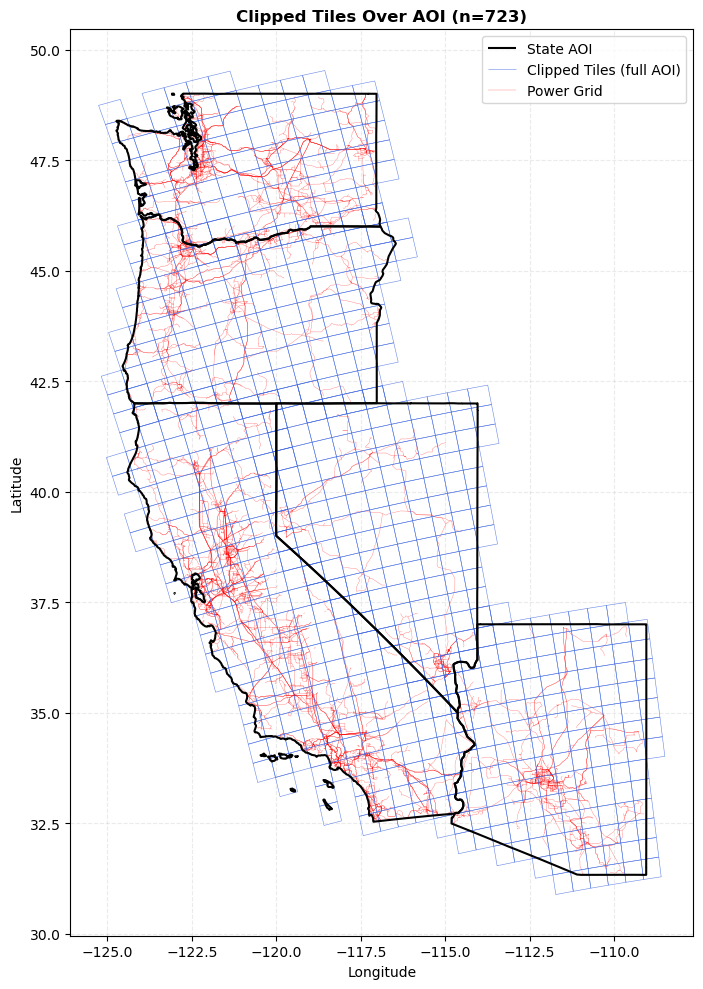

In [15]:
# Clip analysis_grid_gdf to the AOI state boundary (not just power grid lines)
tiles_gdf = gpd.sjoin(
    analysis_grid_gdf, 
    gdf_aoi[["geometry"]],  # Use state boundaries instead of sparse grid lines
    how="inner", 
    predicate="intersects"
).drop(columns=["index_right"])

# Reset index and add tile IDs
tiles_gdf = tiles_gdf.reset_index(drop=True)
tiles_gdf["tile_id"] = [f"T{i:07d}" for i in range(len(tiles_gdf))]

print(f"Clipped tiles_gdf: {len(tiles_gdf)} cells (was {len(analysis_grid_gdf)})")
print(f"CRS: {tiles_gdf.crs}")
print(f"Bounds: {tiles_gdf.total_bounds}")

# Quick plot
fig, ax = plt.subplots(figsize=(12, 10))
gdf_aoi.to_crs("EPSG:4326").boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=3, label="State AOI")
tiles_gdf.to_crs("EPSG:4326").boundary.plot(ax=ax, color="royalblue", linewidth=0.4, alpha=0.8, zorder=2, label="Clipped Tiles (full AOI)")
gdf_powergrid_aoi.to_crs("EPSG:4326").plot(ax=ax, color="red", linewidth=0.3, alpha=0.5, zorder=1, label="Power Grid")
ax.set_title(f"Clipped Tiles Over AOI (n={len(tiles_gdf)})", fontsize=12, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [143]:

print(f"\n{'='*60}")
print(f"Standardizing all geodataframes to {crs_analysis}")
print(f"{'='*60}")

# Reproject tiles_gdf to match
if tiles_gdf.crs != crs_analysis:
    print(f"Reprojecting tiles_gdf from {tiles_gdf.crs} to {crs_analysis}...")
    tiles_gdf = tiles_gdf.to_crs(crs_analysis)
    print("✓ tiles_gdf reprojected")

# Ensure gdf_aoi matches (should already be 4326)
if gdf_aoi.crs != crs_analysis:
    print(f"Reprojecting gdf_aoi from {gdf_aoi.crs} to {crs_analysis}...")
    gdf_aoi = gdf_aoi.to_crs(crs_analysis)
    print("✓ gdf_aoi reprojected")

print(f"\nFinal CRS verification:")
print(f"  gdf_aoi: {gdf_aoi.crs}")
print(f"  tiles_gdf: {tiles_gdf.crs}")
print(f"  gdf_powergrid_aoi: {gdf_powergrid_aoi.crs}")


Standardizing all geodataframes to EPSG:4326

Final CRS verification:
  gdf_aoi: EPSG:4326
  tiles_gdf: EPSG:4326
  gdf_powergrid_aoi: EPSG:4326


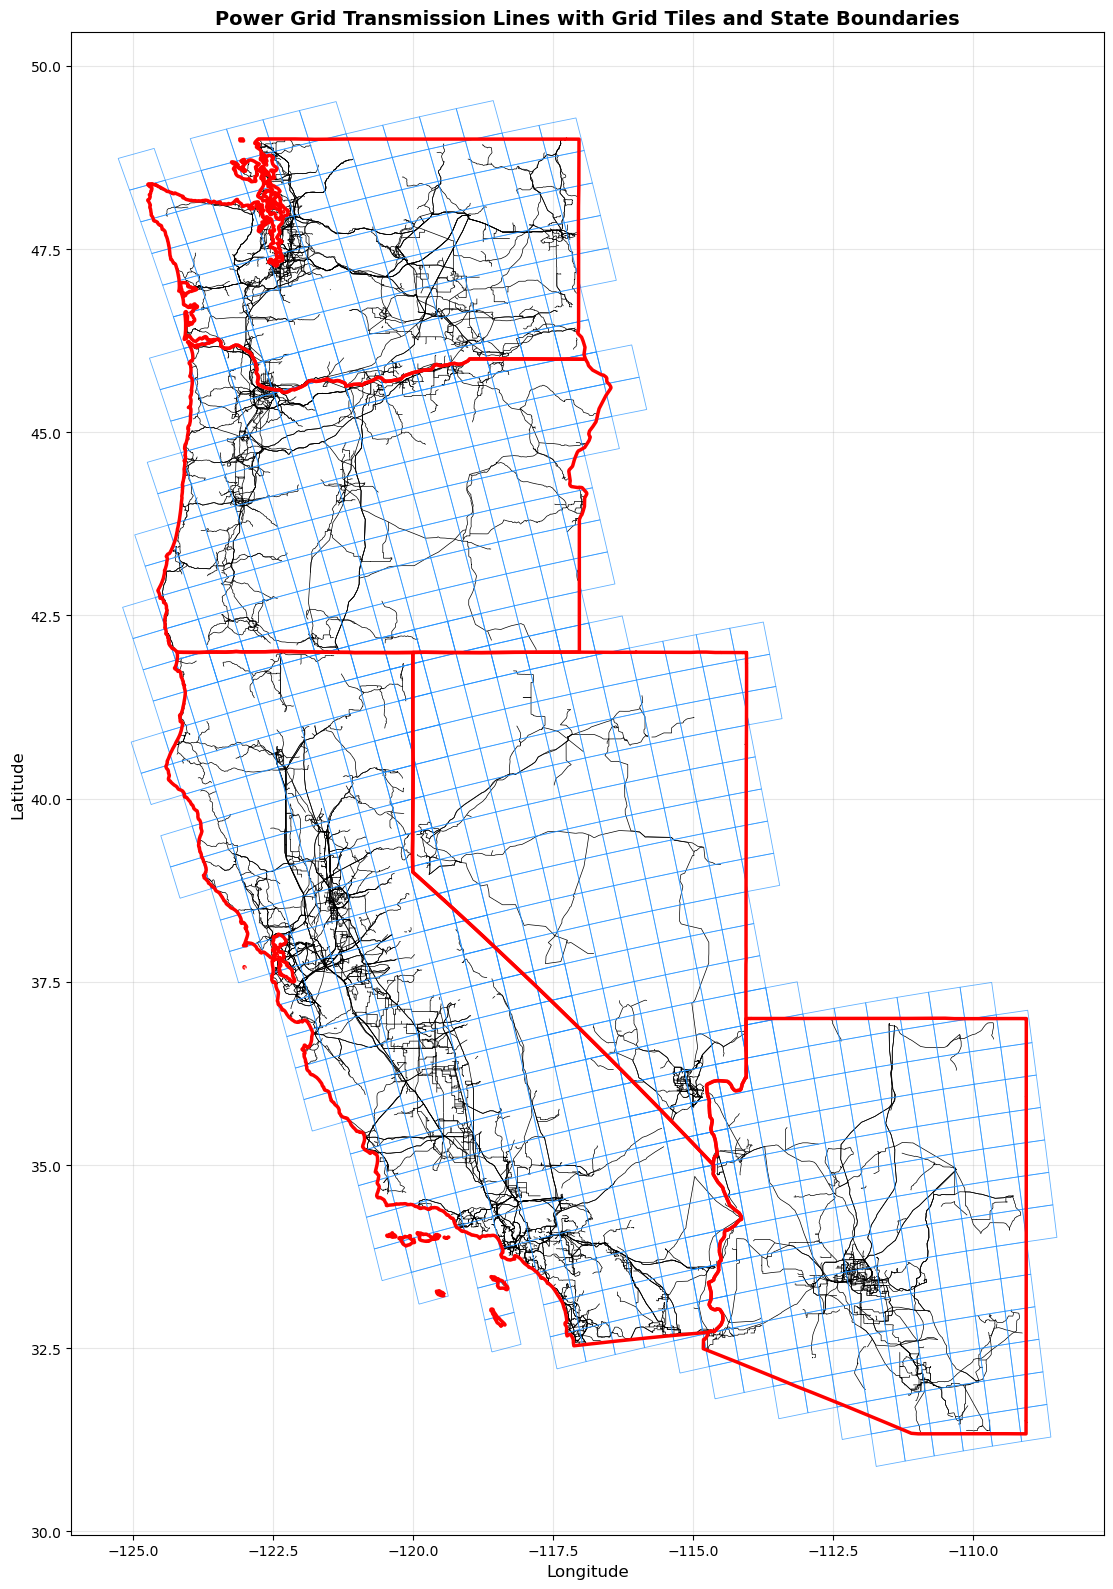

In [16]:
# Create figure and axes
fig, ax = plt.subplots(figsize=(20, 16))

# Ensure layer CRS consistency for plotting
if tiles_gdf.crs != gdf_aoi.crs:
    tiles_plot = tiles_gdf.to_crs(gdf_aoi.crs)
else:
    tiles_plot = tiles_gdf

if gdf_powergrid_aoi.crs != gdf_aoi.crs:
    powergrid_plot = gdf_powergrid_aoi.to_crs(gdf_aoi.crs)
else:
    powergrid_plot = gdf_powergrid_aoi

# Plot power grid transmission lines
powergrid_plot.plot(ax=ax, color='black', linewidth=0.5, label='Transmission Lines', zorder=2)

# Overlay grid tiles
tiles_plot.boundary.plot(ax=ax, color='dodgerblue', linewidth=0.6, alpha=0.7, label='Grid Tiles', zorder=3)

# Overlay state boundaries on top with different styling
gdf_aoi.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2.5, label='State Boundaries', zorder=4)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Power Grid Transmission Lines with Grid Tiles and State Boundaries', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hazards data readers and mapping to the gdf_tiles

In [63]:
day = "2024-06-16"


In [17]:
def _hourly_reduce(da, agg="mean"):
    if "time" not in da.dims:
        return da
    if agg == "max_abs":
        return np.abs(da).resample(time="1h").max()
    if agg == "mean":
        return da.resample(time="1h").mean()
    if agg == "max":
        return da.resample(time="1h").max()
    if agg == "min":
        return da.resample(time="1h").min()
    if agg == "sum":
        return da.resample(time="1h").sum()
    raise ValueError("agg must be one of: max_abs, mean, max, min, sum")

def _hourly_day_index(day_like):
    day0 = pd.to_datetime(day_like).normalize()
    return pd.date_range(day0, day0 + pd.Timedelta(hours=23), freq="1h")


def enforce_full_tile_hours(gdf_tiles, df_hazard, hours):
    """
    Enforce full tile x hour skeleton and left-join hazard data on [tile_id, time].
    """
    tiles = gdf_tiles.copy().reset_index(drop=True)
    if "tile_id" not in tiles.columns:
        tiles["tile_id"] = [f"T{i:07d}" for i in range(len(tiles))]

    tile_cols = [c for c in ["tile_id", "j", "i", "geometry"] if c in tiles.columns]
    skeleton = pd.DataFrame({"time": pd.to_datetime(hours)}).merge(tiles[tile_cols], how="cross")

    # avoid geometry duplication during merge
    hazard = df_hazard.drop(columns=[c for c in ["geometry", "j", "i"] if c in df_hazard.columns], errors="ignore")
    out = skeleton.merge(hazard, on=["tile_id", "time"], how="left")

    return gpd.GeoDataFrame(out, geometry="geometry", crs=tiles.crs)




## Space Weather

In [18]:
# to use GeoE (NOAA) or dB (SuperMAG)?
#  --> NOAA, for now

import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import requests
from pathlib import Path

def _find_coord_name(ds, candidates):
    for c in candidates:
        if c in ds.coords:
            return c
    raise KeyError(f"None of {candidates} found in coords: {list(ds.coords)}")

def swpc_geoelectric_url(date_like):
    dt = pd.to_datetime(date_like)
    ymd = dt.strftime("%Y%m%d")
    return f"https://services.swpc.noaa.gov/netcdf/geoelectric/InterMagEarthScope/{ymd}-empirical-EMTF-2022.12-2022.12.nc"

def load_swpc_geoelectric_ds(date_like, cache_dir="/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/cache/swpc_geoelectric", force_download=False):
    url = swpc_geoelectric_url(date_like)
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    local_fp = cache_dir / Path(url).name

    if force_download or not local_fp.exists():
        r = requests.get(url, timeout=60)
        if r.status_code != 200:
            raise FileNotFoundError(f"File not found or inaccessible: {url} (status {r.status_code})")
        local_fp.write_bytes(r.content)

    ds = xr.open_dataset(local_fp)
    return ds, local_fp, url




def _ensure_swpc_time_datetime(ds, date_like):
    if "time" not in ds.coords:
        raise KeyError("SWPC dataset has no 'time' coordinate.")
    t = ds["time"].values
    if np.issubdtype(np.asarray(t).dtype, np.datetime64):
        return ds.sortby("time")

    # SWPC daily files: UT seconds of day
    base = pd.to_datetime(date_like).normalize()
    t_sec = pd.to_numeric(pd.Series(t), errors="coerce").to_numpy()
    if np.isnan(t_sec).any():
        raise ValueError("Could not parse SWPC 'time' as numeric UT seconds.")
    t_dt = base + pd.to_timedelta(t_sec, unit="s")
    return ds.assign_coords(time=("time", t_dt)).sortby("time")




def map_swpc_to_tiles_hourly(
    date_like,
    gdf_tiles,
    var_names=("Ex", "Ey", "Quality"),
    hourly_agg="max_abs",
    enforce_24h=True,
):
    ds, local_fp, url = load_swpc_geoelectric_ds(date_like)
    ds = _ensure_swpc_time_datetime(ds, date_like)

    for req in ["latitude", "longitude"]:
        if req not in ds.data_vars:
            raise KeyError(f"Required SWPC variable missing: {req}")

    gridpt = gpd.GeoDataFrame(
        {"gridpt": np.arange(ds.sizes["gridpt"], dtype=int)},
        geometry=gpd.points_from_xy(ds["longitude"].values, ds["latitude"].values),
        crs="EPSG:4326",
    )

    tiles = gdf_tiles.copy().reset_index(drop=True)
    if "tile_id" not in tiles.columns:
        tiles["tile_id"] = [f"T{i:07d}" for i in range(len(tiles))]
    tiles["tile_row"] = np.arange(len(tiles), dtype=int)

    # centroid in projected CRS
    tiles_m = tiles.to_crs("EPSG:5070")
    cent_m = gpd.GeoDataFrame(
        tiles_m[["tile_row"]],
        geometry=tiles_m.geometry.centroid,
        crs="EPSG:5070",
    )

    gridpt_m = gridpt.to_crs("EPSG:5070")
    nn = gpd.sjoin_nearest(
        cent_m,
        gridpt_m[["gridpt", "geometry"]],
        how="left",
        distance_col="nn_dist_m",
    ).sort_values("tile_row")

    grid_idx = nn["gridpt"].to_numpy().astype(int)
    dist_km = nn["nn_dist_m"].to_numpy() / 1000.0

    data_vars = {}
    for v in var_names:
        if v not in ds.data_vars:
            continue
        da = ds[v]
        if "time" not in da.dims or "gridpt" not in da.dims:
            continue

        sampled = da.isel(gridpt=xr.DataArray(grid_idx, dims="tile"))  # (time, tile)
        sampled_h = _hourly_reduce(sampled, agg=hourly_agg)            # (time, tile)
        data_vars[f"{v}_{hourly_agg}_h"] = sampled_h

    if not data_vars:
        raise ValueError("No SWPC variables mapped. Check var_names and dataset contents.")

    ds_tile = xr.Dataset(data_vars).sortby("time")

    if enforce_24h:
        hours = _hourly_day_index(date_like)
        ds_tile = ds_tile.reindex(time=hours)

    df = ds_tile.to_dataframe().reset_index()

    tile_meta = tiles[["tile_row", "tile_id", "geometry"]].copy()
    tile_meta["swpc_gridpt"] = grid_idx
    tile_meta["swpc_nn_dist_km"] = dist_km

    out = (
        df.merge(tile_meta, left_on="tile", right_on="tile_row", how="left")
          .drop(columns=["tile", "tile_row"])
    )
    out = gpd.GeoDataFrame(out, geometry="geometry", crs=tiles.crs)

    print(f"Loaded: {local_fp}")
    print(f"Source: {url}")
    print(f"Rows: {len(out)} (tile x hour)")
    print(f"Tiles: {out['tile_id'].nunique()} | Hours: {out['time'].nunique()}")
    return out










In [19]:
# Example
# ds, local_fp, url = load_swpc_geoelectric_ds("2024-06-16")


# Space weather: hourly from 60-sec
tiles_geoe_h = map_swpc_to_tiles_hourly(
    "2024-06-16",
    gdf_tiles=tiles_gdf,
    var_names=("Ex", "Ey", "Quality"),
    hourly_agg="max_abs",
)

tiles_geoe_h.head()

Loaded: /Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/cache/swpc_geoelectric/20240616-empirical-EMTF-2022.12-2022.12.nc
Source: https://services.swpc.noaa.gov/netcdf/geoelectric/InterMagEarthScope/20240616-empirical-EMTF-2022.12-2022.12.nc
Rows: 17352 (tile x hour)
Tiles: 723 | Hours: 24


,time,Ex_max_abs_h,Ey_max_abs_h,Quality_max_abs_h,tile_id,geometry,swpc_gridpt,swpc_nn_dist_km
0,2024-06-16,4.417364,11.412093,5.0,T0000000,"POLYGON ((-111.72577 30.88777, -111.20806 30.9...",217,62.330114
1,2024-06-16,4.417364,11.412093,5.0,T0000001,"POLYGON ((-111.20806 30.96064, -110.68943 31.0...",217,31.381712
2,2024-06-16,1.222410,5.124331,5.0,T0000002,"POLYGON ((-110.68943 31.03107, -110.16993 31.0...",218,23.823083
3,2024-06-16,2.075091,8.770546,5.0,T0000003,"POLYGON ((-110.16993 31.09907, -109.64956 31.1...",219,16.924448
4,2024-06-16,9.162453,24.030678,5.0,T0000004,"POLYGON ((-109.64956 31.16462, -109.12837 31.2...",220,11.417117


## Terrestrial Weather

In [66]:
# one of Yuliya's merged files
terr_wx_data_file = '/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/terrestrial_weather/weather_CONUS_20240616.nc'
terr_wx_data = xr.open_dataset(terr_wx_data_file)

terr_wx_data


<xarray.Dataset> Size: 36MB
Dimensions:                            (time: 24, y: 55, x: 104)
Coordinates:
  * time                               (time) datetime64[ns] 192B 2024-06-16 ...
  * y                                  (y) float64 440B 6.668e+05 ... 3.367e+06
  * x                                  (x) float64 832B -2.918e+06 ... 2.232e+06
Data variables: (12/35)
    MAX_SHEAR                          (time, y, x) float64 1MB ...
    MXDV                               (time, y, x) float64 1MB ...
    PROB                               (time, y, x) float64 1MB ...
    MAXSIZE                            (time, y, x) float64 1MB ...
    VIL                                (time, y, x) float64 1MB ...
    MAX_REFLECT                        (time, y, x) float64 1MB ...
    ...                                 ...
    sp                                 (time, y, x) float64 1MB ...
    vis                                (time, y, x) float64 1MB ...
    ceil                               (time, y, x) float64 1MB ...
    tcc                                (time, y, x) float64 1MB ...
    orog                               (time, y, x) float64 1MB ...
    i10fg                              (time, y, x) float64 1MB ...
Attributes:
    region:   CONUS
    date:     20240616
    created:  2026-03-06T03:01:34.711568

In [67]:
import pandas as pd
import numpy as np
import geopandas as gpd




def map_terr_wx_to_tiles_hourly(
    terr_wx_ds,
    gdf_tiles,
    var_names=None,
    day_like=None,                # e.g. "2024-06-16"
    enforce_24h=True,             # force exactly 24 rows per tile for day_like
    time_dim_candidates=("time", "valid_time", "datetime"),
    y_dim_candidates=("y", "lat", "latitude", "j"),
    x_dim_candidates=("x", "lon", "longitude", "i"),
    enforce_hourly=False,
    hourly_agg="mean",
):
    tiles = gdf_tiles.copy().reset_index(drop=True)
    if "tile_id" not in tiles.columns:
        tiles["tile_id"] = [f"T{i:07d}" for i in range(len(tiles))]
    if not {"j", "i"}.issubset(tiles.columns):
        raise ValueError("gdf_tiles must contain 'j' and 'i'.")

    ds = terr_wx_ds
    time_dim = next((d for d in time_dim_candidates if d in ds.dims or d in ds.coords), None)
    y_dim = next((d for d in y_dim_candidates if d in ds.dims), None)
    x_dim = next((d for d in x_dim_candidates if d in ds.dims), None)
    if time_dim is None or y_dim is None or x_dim is None:
        raise KeyError(f"Could not identify dims. dims={dict(ds.dims)}")

    tile_j = tiles["j"].to_numpy().astype(int)
    tile_i = tiles["i"].to_numpy().astype(int)

    ny, nx = ds.sizes[y_dim], ds.sizes[x_dim]
    if (tile_j < 0).any() or (tile_j >= ny).any() or (tile_i < 0).any() or (tile_i >= nx).any():
        raise IndexError("Some tile (j, i) are out of bounds.")

    if var_names is None:
        var_names = [v for v in ds.data_vars if {time_dim, y_dim, x_dim}.issubset(set(ds[v].dims))]

    data_vars = {}
    for v in var_names:
        da = ds[v]
        if not {time_dim, y_dim, x_dim}.issubset(set(da.dims)):
            continue

        da = da.transpose(time_dim, y_dim, x_dim)
        sampled = da.isel({
            y_dim: xr.DataArray(tile_j, dims="tile"),
            x_dim: xr.DataArray(tile_i, dims="tile"),
        }).rename({time_dim: "time"})  # (time, tile)

        if enforce_hourly:
            sampled = _hourly_reduce(sampled, agg=hourly_agg)

        data_vars[f"{v}_h"] = sampled

    if not data_vars:
        raise ValueError("No terrestrial weather variables mapped.")

    ds_tile = xr.Dataset(data_vars).sortby("time")

    if enforce_24h:
        if day_like is None:
            day_like = pd.to_datetime(ds_tile["time"].values[0]).normalize()
        ds_tile = ds_tile.reindex(time=_hourly_day_index(day_like))

    df = ds_tile.to_dataframe().reset_index()  # time, tile, vars...
    tile_meta = tiles[["tile_id"]].copy()
    tile_meta["tile"] = np.arange(len(tiles), dtype=int)

    out = df.merge(tile_meta, on="tile", how="left").drop(columns=["tile"])
    out = enforce_full_tile_hours(tiles, out, _hourly_day_index(day_like if day_like is not None else out["time"].min()))

    print(f"Rows: {len(out)} (tile x hour)")
    print(f"Tiles: {out['tile_id'].nunique()} | Hours: {out['time'].nunique()}")
    return out




In [68]:
tiles_wx_h = map_terr_wx_to_tiles_hourly(
    terr_wx_data,
    gdf_tiles=tiles_gdf,
    day_like=day,
    enforce_24h=True,
    enforce_hourly=False,
)
tiles_wx_h.head()

Rows: 17352 (tile x hour)
Tiles: 723 | Hours: 24


,time,tile_id,j,i,geometry,y,x,MAX_SHEAR_h,MXDV_h,PROB_h,...,wdir10_h,t2m_h,d2m_h,sh2_h,sp_h,vis_h,ceil_h,tcc_h,orog_h,i10fg_h
0,2024-06-16,T0000000,7,29,"POLYGON ((-111.20806 30.96064, -111.29216 31.4...",1.016760e+06,-1.467542e+06,NaN,NaN,NaN,...,254.761480,311.409592,271.184158,0.003654,90547.737245,16000.000000,16000.0,0.522857,919.798469,7.488316
1,2024-06-16,T0000001,7,30,"POLYGON ((-110.68943 31.03107, -110.77076 31.4...",1.016760e+06,-1.417542e+06,NaN,NaN,NaN,...,263.342821,309.364692,273.701077,0.004694,86802.489744,16000.000000,16000.0,0.191000,1291.369231,6.863231
2,2024-06-16,T0000002,7,31,"POLYGON ((-110.16993 31.09907, -110.24846 31.5...",1.016760e+06,-1.367542e+06,NaN,NaN,NaN,...,265.346923,307.831385,269.859000,0.003601,84208.446154,15999.356410,16000.0,0.000000,1554.607692,7.868949
3,2024-06-16,T0000003,7,32,"POLYGON ((-109.64956 31.16462, -109.7253 31.60...",1.016760e+06,-1.317542e+06,NaN,NaN,NaN,...,255.030534,309.070407,265.373995,0.002503,85270.653944,15982.389313,16000.0,0.000000,1441.486005,9.325903
4,2024-06-16,T0000004,7,33,"POLYGON ((-109.12837 31.22773, -109.20129 31.6...",1.016760e+06,-1.267542e+06,NaN,NaN,NaN,...,238.283375,309.881738,261.044433,0.001764,86257.183879,15665.060453,16000.0,0.000000,1333.685139,9.651814


In [73]:
# tiles_wx_h.columns.to_list()

## Wildfire

In [69]:
wildfire_data_file1 = '/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/2024_Fires_AOI/CA3480311887820240615.gpkg'
# wildfire_data_file2 = '/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data2024_Fires_AOI/AZ3446811081220240703.gpkg'

wildfire_data = gpd.read_file(wildfire_data_file1)

wildfire_data


/Users/ryanmc/miniforge3/envs/spwxr_network_new/lib/python3.9/site-packages/pyogrio/geopandas.py:265: UserWarning:

More than one layer found in 'CA3480311887820240615.gpkg': 'perimeter' (default), 'fireline', 'newfirepix'. Specify layer parameter to avoid this warning.



,t,n_pixels,n_newpixels,farea,fperim,duration,pixden,sumFRP,flinelen,geometry
0,2024-06-16 00:00:00,168,168,2.980947e+07,48.974630,0,0.000006,1204.24,44.229611,"MULTIPOLYGON (((-118.86691 34.76808, -118.8692..."
1,2024-06-16 12:00:00,243,75,3.705273e+07,53.094120,0.5,0.000007,4782.57,13.314270,"MULTIPOLYGON (((-118.86922 34.77353, -118.8692..."
2,2024-06-17 00:00:00,275,32,4.517805e+07,59.142905,1,0.000006,4846.42,10.017592,"MULTIPOLYGON (((-118.86928 34.7737, -118.86932..."
3,2024-06-17 12:00:00,276,1,4.517805e+07,59.142905,1.5,0.000006,4858.29,0.000000,"MULTIPOLYGON (((-118.86932 34.77386, -118.8693..."


In [121]:
# # # ...existing code...
# import matplotlib.pyplot as plt
# import geopandas as gpd

# # Ensure wildfire CRS is geographic for lon/lat readout
# wf0 = wildfire_data.copy()
# if wf0.crs is None:
#     raise ValueError("wildfire_data has no CRS defined.")
# wf0 = wf0.to_crs("EPSG:4326")

# # First entry geometry
# geom0 = wf0.iloc[-1].geometry
# if geom0 is None or geom0.is_empty:
#     raise ValueError("First wildfire geometry is empty.")

# # Representative lat/lon
# if geom0.geom_type == "Point":
#     lon0, lat0 = float(geom0.x), float(geom0.y)
# else:
#     c0 = geom0.centroid
#     lon0, lat0 = float(c0.x), float(c0.y)

# print(f"First wildfire entry centroid lon/lat: ({lon0:.6f}, {lat0:.6f})")
# print(f"Geometry type: {geom0.geom_type}")

# # Build point layer
# pt = gpd.GeoDataFrame(
#     [{"label": "wildfire_data[0]"}],
#     geometry=gpd.points_from_xy([lon0], [lat0]),
#     crs="EPSG:4326",
# )

# # California boundary (prefer gdf_aoi if it has state names)
# if "name" in gdf_aoi.columns:
#     ca = gdf_aoi[gdf_aoi["name"].astype(str).str.lower().eq("california")].to_crs("EPSG:4326")
#     if ca.empty:
#         ca = gdf_aoi.to_crs("EPSG:4326")
# else:
#     ca = gdf_aoi.to_crs("EPSG:4326")

# fig, ax = plt.subplots(figsize=(8, 10))
# ca.boundary.plot(ax=ax, color="black", linewidth=1.5)
# pt.plot(ax=ax, color="red", markersize=60, zorder=3)

# ax.set_title("First Wildfire Entry Location (Centroid) on California Map")
# ax.set_xlabel("Longitude")
# ax.set_ylabel("Latitude")
# ax.grid(alpha=0.25, linestyle="--")

# # zoom to California if available
# xmin, ymin, xmax, ymax = ca.total_bounds
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)

# plt.tight_layout()
# plt.show()
# # ...existing code...wildfire_data.iloc[0]['geometry']


In [39]:
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors
# import pandas as pd
# import geopandas as gpd

# # --- Check available date columns ---
# print("Wildfire data columns:")
# print(wildfire_data.dtypes)
# print(wildfire_data.head(3))

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import geopandas as gpd

# --- Prepare wildfire data ---
wf = wildfire_data.copy()
wf["t"] = pd.to_datetime(wf["t"])
wf = wf.dropna(subset=["t"])
wf = wf.to_crs("EPSG:4326")
wf = wf.sort_values("t").reset_index(drop=True)

# Assign a distinct color per unique date
unique_dates = wf["t"].dt.strftime("%Y-%m-%d").unique()
colors = px.colors.qualitative.Alphabet[:len(unique_dates)]
if len(unique_dates) > len(colors):
    # cycle if more dates than colors
    colors = (colors * (len(unique_dates) // len(colors) + 1))[:len(unique_dates)]
date_color_map = dict(zip(unique_dates, colors))

# --- Build figure ---
fig = go.Figure()

# Power grid lines
for _, row in gdf_powergrid_aoi.to_crs("EPSG:4326").iterrows():
    geom = row.geometry
    if geom.geom_type == "LineString":
        xs, ys = geom.xy
        fig.add_trace(go.Scattergeo(
            lon=list(xs), lat=list(ys),
            mode="lines",
            line=dict(color="gray", width=0.5),
            opacity=0.4,
            showlegend=False,
            hoverinfo="skip",
            name="Power Grid",
        ))
    elif geom.geom_type == "MultiLineString":
        for line in geom.geoms:
            xs, ys = line.xy
            fig.add_trace(go.Scattergeo(
                lon=list(xs), lat=list(ys),
                mode="lines",
                line=dict(color="gray", width=0.5),
                opacity=0.4,
                showlegend=False,
                hoverinfo="skip",
            ))

# AOI boundary
for _, row in gdf_aoi.to_crs("EPSG:4326").iterrows():
    geom = row.geometry
    polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for poly in polys:
        xs, ys = poly.exterior.xy
        fig.add_trace(go.Scattergeo(
            lon=list(xs), lat=list(ys),
            mode="lines",
            line=dict(color="black", width=1.5),
            showlegend=False,
            hoverinfo="skip",
        ))

# Wildfire polygons — one trace per unique date for legend grouping
for date_str, color in date_color_map.items():
    subset = wf[wf["t"].dt.strftime("%Y-%m-%d") == date_str]
    first = True
    for _, row in subset.iterrows():
        geom = row.geometry
        polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for poly in polys:
            xs, ys = poly.exterior.xy
            fig.add_trace(go.Scattergeo(
                lon=list(xs) + [xs[0]],
                lat=list(ys) + [ys[0]],
                mode="lines",
                fill="toself",
                fillcolor=color,
                opacity=0.5,
                line=dict(color=color, width=1),
                name=date_str,
                legendgroup=date_str,
                showlegend=first,  # only show once per date in legend
                hovertemplate=(
                    f"<b>Date:</b> {date_str}<br>"
                    f"<b>Area:</b> {row['farea']:.1f} ha<br>"
                    f"<b>Perimeter:</b> {row['fperim']:.1f} km<br>"
                    f"<b>FRP:</b> {row['sumFRP']:.1f}<br>"
                    f"<b>Duration:</b> {row['duration']}<extra></extra>"
                ),
            ))
            first = False

# --- Layout ---
xmin, ymin, xmax, ymax = gdf_aoi.to_crs("EPSG:4326").total_bounds

fig.update_layout(
    title=dict(
        text=f"Wildfire Perimeters (n={len(wf)}) — {wf['t'].min().strftime('%Y-%m-%d')} → {wf['t'].max().strftime('%Y-%m-%d')}",
        font=dict(size=14)
    ),
    geo=dict(
        scope="usa",
        lonaxis=dict(range=[xmin, xmax]),
        lataxis=dict(range=[ymin, ymax]),
        showland=True,
        landcolor="whitesmoke",
        showlakes=True,
        lakecolor="lightblue",
        showrivers=True,
        rivercolor="lightblue",
        showcoastlines=True,
        coastlinecolor="lightgray",
        showframe=False,
    ),
    legend=dict(
        title="Fire Date",
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="gray",
        borderwidth=1,
        font=dict(size=10),
    ),
    margin=dict(l=0, r=0, t=40, b=0),
    height=700,
    width=900,
)

fig.show()

In [70]:
def map_wildfire_to_tiles(
    wildfire_gdf,
    gdf_tiles,
    time_col="t",
    final_end=None,
    overlap_crs="EPSG:5070",
):
    """
    Interval mapping:
      row k active on [t_k, t_{k+1}), last row uses final_end (or t_last).
    Returns tile x interval rows (no hourly expansion yet).
    """
    wf = wildfire_gdf.copy()
    wf[time_col] = pd.to_datetime(wf[time_col], errors="coerce")
    wf = wf.dropna(subset=[time_col, "geometry"]).sort_values(time_col).reset_index(drop=True)
    if wf.empty:
        raise ValueError("No valid wildfire rows.")

    wf["time_start"] = wf[time_col]
    wf["time_end"] = wf[time_col].shift(-1)
    wf.loc[wf.index[-1], "time_end"] = pd.to_datetime(final_end) if final_end is not None else wf.loc[wf.index[-1], time_col]
    wf = wf[wf["time_end"] > wf["time_start"]].copy()
    wf["interval_id"] = np.arange(len(wf), dtype=int)

    tiles = gdf_tiles.copy().reset_index(drop=True)
    if "tile_id" not in tiles.columns:
        tiles["tile_id"] = [f"T{i:07d}" for i in range(len(tiles))]
    key_cols = [c for c in ["tile_id", "j", "i"] if c in tiles.columns]

    tiles_p = tiles[key_cols + ["geometry"]].to_crs(overlap_crs).copy()
    tiles_p["tile_area_m2"] = tiles_p.geometry.area
    wf_p = wf.to_crs(overlap_crs).copy()

    hits = []
    for _, fire in wf_p.iterrows():
        cand = tiles_p[tiles_p.intersects(fire.geometry)].copy()
        if cand.empty:
            continue

        inter_area = cand.geometry.intersection(fire.geometry).area
        cand["interval_id"] = int(fire["interval_id"])
        cand["time_start"] = fire["time_start"]
        cand["time_end"] = fire["time_end"]
        cand["wildfire_active"] = 1
        cand["wildfire_n_polys"] = 1
        cand["wildfire_area_tile_m2"] = inter_area
        cand["wildfire_frac_tile"] = (inter_area / cand["tile_area_m2"]).clip(upper=1.0)
        cand["wildfire_source_farea_ha"] = pd.to_numeric(fire.get("farea", np.nan), errors="coerce")
        cand["wildfire_source_fperim_km"] = pd.to_numeric(fire.get("fperim", np.nan), errors="coerce")
        cand["wildfire_source_sumFRP"] = pd.to_numeric(fire.get("sumFRP", np.nan), errors="coerce")
        hits.append(cand[key_cols + [
            "interval_id", "time_start", "time_end",
            "wildfire_active", "wildfire_n_polys", "wildfire_area_tile_m2",
            "wildfire_frac_tile", "wildfire_source_farea_ha",
            "wildfire_source_fperim_km", "wildfire_source_sumFRP"
        ]])

    if not hits:
        return pd.DataFrame(columns=key_cols + ["interval_id", "time_start", "time_end"])

    out = pd.concat(hits, ignore_index=True)
    out = (
        out.groupby(key_cols + ["interval_id", "time_start", "time_end"], dropna=False)
        .agg(
            wildfire_active=("wildfire_active", "max"),
            wildfire_n_polys=("wildfire_n_polys", "sum"),
            wildfire_area_tile_m2=("wildfire_area_tile_m2", "sum"),
            wildfire_frac_tile=("wildfire_frac_tile", "sum"),
            wildfire_source_farea_ha=("wildfire_source_farea_ha", "sum"),
            wildfire_source_fperim_km=("wildfire_source_fperim_km", "sum"),
            wildfire_source_sumFRP=("wildfire_source_sumFRP", "sum"),
        )
        .reset_index()
    )
    out["wildfire_frac_tile"] = out["wildfire_frac_tile"].clip(upper=1.0)
    return out


def map_wildfire_to_tiles_hourly(
    wildfire_gdf,
    gdf_tiles,
    day_like,                     # required for exact 24h skeleton
    time_col="t",
    final_end=None,
    overlap_crs="EPSG:5070",
):
    wf_intervals = map_wildfire_to_tiles(
        wildfire_gdf,
        gdf_tiles=gdf_tiles,
        time_col=time_col,
        final_end=final_end,
        overlap_crs=overlap_crs,
    ).copy()

    if wf_intervals.empty:
        out = enforce_full_tile_hours(gdf_tiles, pd.DataFrame(columns=["tile_id", "time"]), _hourly_day_index(day_like))
        for c in ["wildfire_active", "wildfire_n_polys", "wildfire_area_tile_m2", "wildfire_frac_tile",
                  "wildfire_source_farea_ha", "wildfire_source_fperim_km", "wildfire_source_sumFRP"]:
            out[c] = 0
        out["wildfire_active"] = out["wildfire_active"].astype(int)
        out["wildfire_n_polys"] = out["wildfire_n_polys"].astype(int)
        return out

    wf_intervals["time_start"] = pd.to_datetime(wf_intervals["time_start"])
    wf_intervals["time_end"] = pd.to_datetime(wf_intervals["time_end"])

    tmp = wf_intervals.copy()
    tmp["h0"] = tmp["time_start"].dt.floor("h")
    tmp["h1"] = (tmp["time_end"] - pd.Timedelta(seconds=1)).dt.floor("h")
    tmp = tmp[tmp["h1"] >= tmp["h0"]].copy()
    tmp["time"] = tmp.apply(lambda r: pd.date_range(r["h0"], r["h1"], freq="1h"), axis=1)
    tmp = tmp.explode("time", ignore_index=True)

    key_cols = [c for c in ["tile_id", "time"] if c in tmp.columns]
    agg = (
        tmp.groupby(key_cols, dropna=False)
        .agg(
            wildfire_active=("wildfire_active", "max"),
            wildfire_n_polys=("wildfire_n_polys", "sum"),
            wildfire_area_tile_m2=("wildfire_area_tile_m2", "sum"),
            wildfire_frac_tile=("wildfire_frac_tile", "sum"),
            wildfire_source_farea_ha=("wildfire_source_farea_ha", "sum"),
            wildfire_source_fperim_km=("wildfire_source_fperim_km", "sum"),
            wildfire_source_sumFRP=("wildfire_source_sumFRP", "sum"),
        )
        .reset_index()
    )
    agg["wildfire_frac_tile"] = agg["wildfire_frac_tile"].clip(upper=1.0)

    out = enforce_full_tile_hours(gdf_tiles, agg, _hourly_day_index(day_like))

    for c in ["wildfire_active", "wildfire_n_polys", "wildfire_area_tile_m2", "wildfire_frac_tile",
              "wildfire_source_farea_ha", "wildfire_source_fperim_km", "wildfire_source_sumFRP"]:
        out[c] = out[c].fillna(0)

    out["wildfire_active"] = out["wildfire_active"].astype(int)
    out["wildfire_n_polys"] = out["wildfire_n_polys"].astype(int)

    print(f"Rows: {len(out)} (tile x hour)")
    print(f"Tiles: {out['tile_id'].nunique()} | Hours: {out['time'].nunique()}")
    return out


In [71]:

tiles_fire_h = map_wildfire_to_tiles_hourly(
    wildfire_data,
    gdf_tiles=tiles_gdf,
    day_like=day,
    time_col="t",
    final_end="2024-06-16 23:59:59",
)

tiles_fire_h.head()

Rows: 17352 (tile x hour)
Tiles: 723 | Hours: 24


,time,tile_id,j,i,geometry,wildfire_active,wildfire_n_polys,wildfire_area_tile_m2,wildfire_frac_tile,wildfire_source_farea_ha,wildfire_source_fperim_km,wildfire_source_sumFRP
0,2024-06-16,T0000000,7,29,"POLYGON ((-111.20806 30.96064, -111.29216 31.4...",0,0,0.0,0.0,0.0,0.0,0.0
1,2024-06-16,T0000001,7,30,"POLYGON ((-110.68943 31.03107, -110.77076 31.4...",0,0,0.0,0.0,0.0,0.0,0.0
2,2024-06-16,T0000002,7,31,"POLYGON ((-110.16993 31.09907, -110.24846 31.5...",0,0,0.0,0.0,0.0,0.0,0.0
3,2024-06-16,T0000003,7,32,"POLYGON ((-109.64956 31.16462, -109.7253 31.60...",0,0,0.0,0.0,0.0,0.0,0.0
4,2024-06-16,T0000004,7,33,"POLYGON ((-109.12837 31.22773, -109.20129 31.6...",0,0,0.0,0.0,0.0,0.0,0.0


In [96]:
tiles_geoe_h['time']

0       2024-06-16 00:00:00
1       2024-06-16 00:00:00
2       2024-06-16 00:00:00
3       2024-06-16 00:00:00
4       2024-06-16 00:00:00
                ...        
17347   2024-06-16 23:00:00
17348   2024-06-16 23:00:00
17349   2024-06-16 23:00:00
17350   2024-06-16 23:00:00
17351   2024-06-16 23:00:00
Name: time, Length: 17352, dtype: datetime64[ns]

In [102]:
tiles_geoe_h

,time,Ex_max_abs_h,Ey_max_abs_h,Quality_max_abs_h,tile_id,geometry,swpc_gridpt,swpc_nn_dist_km
0,2024-06-16 00:00:00,4.417364,11.412093,5.0,T0000000,"POLYGON ((-111.20806 30.96064, -111.29216 31.4...",217,62.330114
1,2024-06-16 00:00:00,4.417364,11.412093,5.0,T0000001,"POLYGON ((-110.68943 31.03107, -110.77076 31.4...",217,31.381712
2,2024-06-16 00:00:00,1.222410,5.124331,5.0,T0000002,"POLYGON ((-110.16993 31.09907, -110.24846 31.5...",218,23.823083
3,2024-06-16 00:00:00,2.075091,8.770546,5.0,T0000003,"POLYGON ((-109.64956 31.16462, -109.7253 31.60...",219,16.924448
4,2024-06-16 00:00:00,9.162453,24.030678,5.0,T0000004,"POLYGON ((-109.12837 31.22773, -109.20129 31.6...",220,11.417117
...,...,...,...,...,...,...,...,...
17347,2024-06-16 23:00:00,NaN,NaN,NaN,T0000718,"POLYGON ((-124.42076 48.43878, -124.61921 48.8...",3302,90.318973
17348,2024-06-16 23:00:00,NaN,NaN,NaN,T0000719,"POLYGON ((-123.13687 48.70067, -123.32739 49.1...",3377,56.777818
17349,2024-06-16 23:00:00,NaN,NaN,NaN,T0000720,"POLYGON ((-122.49105 48.8273, -122.67754 49.26...",3377,53.524451
17350,2024-06-16 23:00:00,NaN,NaN,NaN,T0000721,"POLYGON ((-121.84271 48.951, -122.02509 49.389...",3378,69.246244


In [ ]:
tiles_geoe_h[tiles_geoe_h['time'] == dat]['Ex_max_abs_h'].describe()
# tiles_wx_h['MergedReflectivityComposite_00.50_h'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Ey_max_abs_h, dtype: float64

## Snapshot visualization

In [195]:
tiles_wx_h.columns.to_list()

['time',
 'tile_id',
 'j',
 'i',
 'geometry',
 'y',
 'x',
 'MAX_SHEAR_h',
 'MXDV_h',
 'PROB_h',
 'MAXSIZE_h',
 'VIL_h',
 'MAX_REFLECT_h',
 'MergedBaseReflectivity_00.50_h',
 'MergedReflectivityComposite_00.50_h',
 'FLASH_QPE_ARI01H_00.00_h',
 'FLASH_QPE_ARIMAX_00.00_h',
 'MultiSensor_QPE_01H_Pass2_00.00_h',
 'MultiSensor_QPE_24H_Pass2_00.00_h',
 'RotationTrackML60min_00.50_h',
 'MESH_00.50_h',
 'VII_00.50_h',
 'VIL_Density_00.50_h',
 'PrecipRate_00.00_h',
 'NLDN_CG_001min_AvgDensity_00.00_h',
 'EchoTop_18_00.50_h',
 'PrecipFlag_00.00_h',
 'u10_h',
 'v10_h',
 'wspd10_h',
 'wdir10_h',
 't2m_h',
 'd2m_h',
 'sh2_h',
 'sp_h',
 'vis_h',
 'ceil_h',
 'tcc_h',
 'orog_h',
 'i10fg_h']

In [198]:
wildfire_data['sumFRP']

0    1204.24
1    4782.57
2    4846.42
3    4858.29
Name: sumFRP, dtype: float64

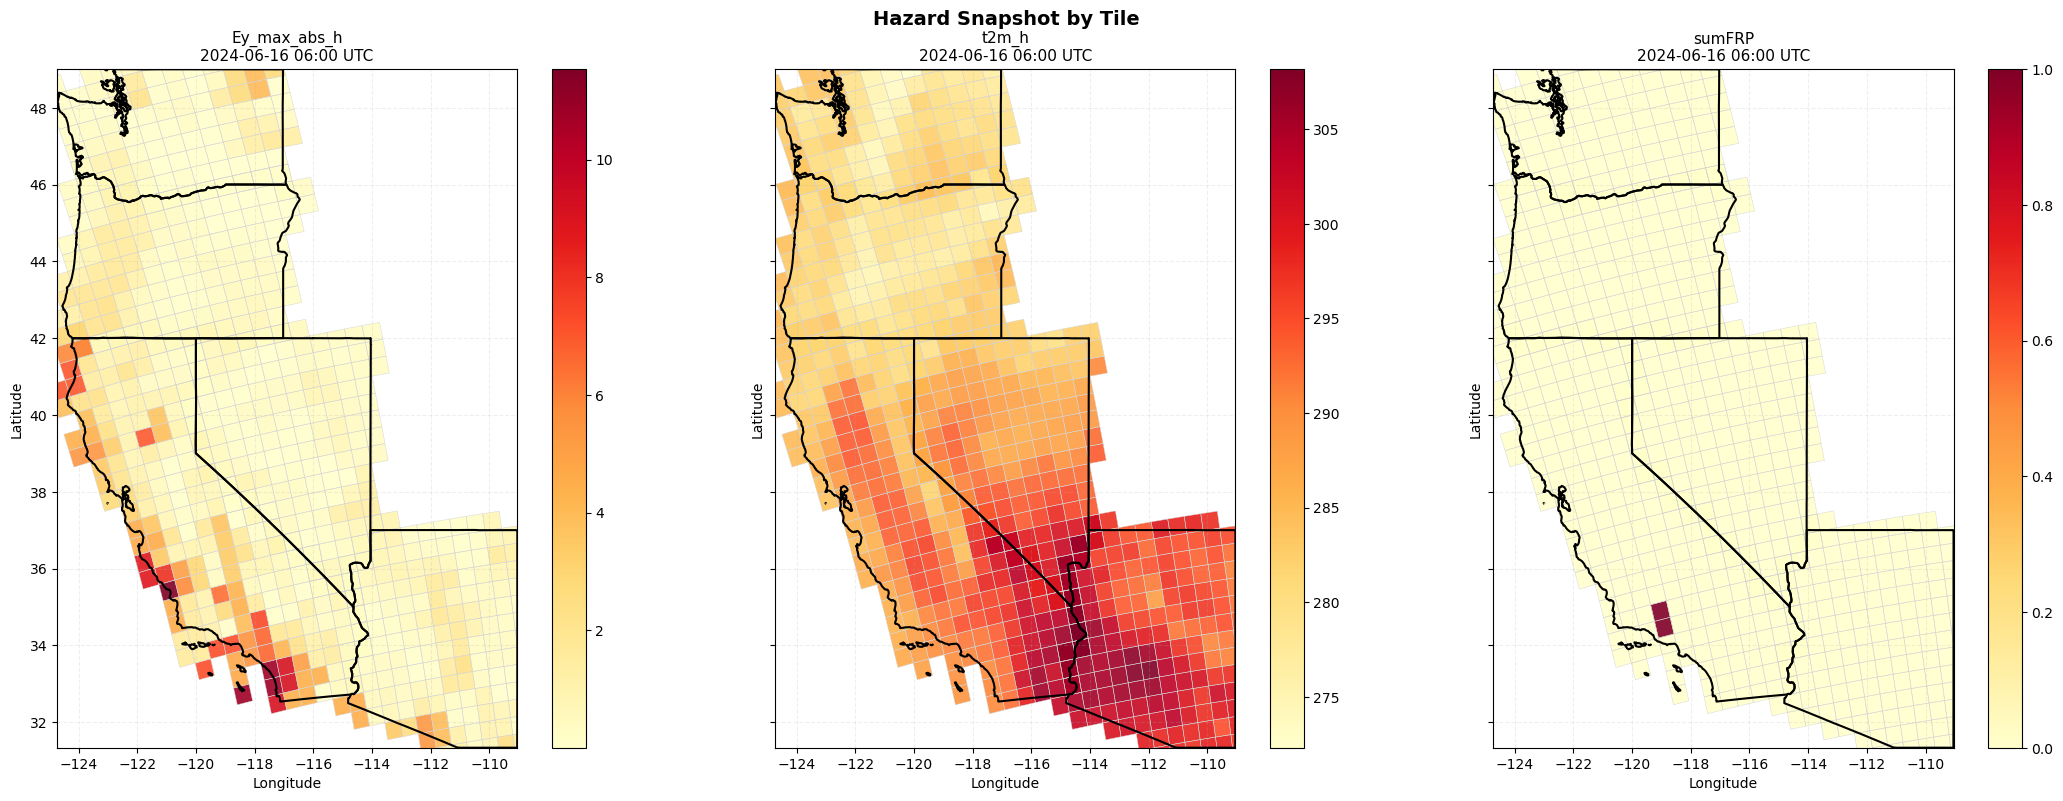

In [199]:
# ...existing code...
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sp_wx_col = "Ey_max_abs_h"
terr_wx_col = 't2m_h' #'MergedReflectivityComposite_00.50_h'
wf_col = 'sumFRP'

def _pick_col(cols, preferred, startswith=None):
    if preferred in cols:
        return preferred
    if startswith is not None:
        cands = [c for c in cols if c.startswith(startswith)]
        if cands:
            return cands[0]
    raise KeyError(f"Column not found: {preferred}")

def _snapshot_at_time(gdf, target_time):
    d = gdf.copy()
    d["time"] = pd.to_datetime(d["time"], errors="coerce")
    d = d.dropna(subset=["time"]).copy()
    if d.empty:
        raise ValueError("No valid time values found.")
    t_sel = min(d["time"].unique(), key=lambda t: abs(t - target_time))
    return d[d["time"] == t_sel].copy(), t_sel

# ---- choose snapshot hour (UTC) ----
snapshot_time = pd.Timestamp(f"{day} 06:00:00")

# ---- column names ----
space_col = _pick_col(tiles_geoe_h.columns, preferred=sp_wx_col)
terr_col  = _pick_col(tiles_wx_h.columns, preferred=terr_wx_col)
# fire_col  = "wildfire_source_sumFRP" if "wildfire_source_sumFRP" in tiles_fire_h.columns else _pick_col(tiles_fire_h.columns, preferred="sumFRP", startswith="wildfire_")
fire_col  = _pick_col(tiles_fire_h.columns, preferred=wf_col, startswith="wildfire_")

# ---- snapshot slices ----
geoe_s, t_geoe = _snapshot_at_time(tiles_geoe_h, snapshot_time)
terr_s, t_terr = _snapshot_at_time(tiles_wx_h, snapshot_time)
fire_s, t_fire = _snapshot_at_time(tiles_fire_h, snapshot_time)

# ---- common CRS/layers ----
plot_crs = crs_analysis #"EPSG:4326"
aoi_plot   = gdf_aoi.to_crs(plot_crs)
tiles_plot = tiles_gdf.to_crs(plot_crs)
geoe_s     = geoe_s.to_crs(plot_crs)
terr_s     = terr_s.to_crs(plot_crs)
fire_s     = fire_s.to_crs(plot_crs)

xmin, ymin, xmax, ymax = aoi_plot.total_bounds

fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharex=True, sharey=True)

layers = [
    (geoe_s, space_col, sp_wx_col, "YlOrRd", t_geoe), #plasma
    (terr_s, terr_col, terr_wx_col, "YlOrRd", t_terr), #viridis
    (fire_s, fire_col, wf_col, "YlOrRd", t_fire), #YlOrRd
]
    
for ax, (g, col, title, cmap, tsel) in zip(axes, layers):
    g = g.copy()
    g[col] = pd.to_numeric(g[col], errors="coerce")  # do NOT fillna(0)

    has_data = g[col].notna().any()

    if has_data:
        g.plot(
            ax=ax,
            column=col,
            cmap=cmap,
            linewidth=0,
            legend=True,
            alpha=0.9,
            missing_kwds={"color": "lightgray", "alpha": 0.2, "label": "No data"},
        )
    else:
        # no valid values at this time: draw empty tiles only
        tiles_plot.boundary.plot(ax=ax, color="lightgray", linewidth=0.35, alpha=0.9, zorder=1)
        ax.text(
            0.5, 0.5, "No data at this time",
            transform=ax.transAxes, ha="center", va="center", fontsize=11, color="dimgray"
        )

    # always overlay context layers
    tiles_plot.boundary.plot(ax=ax, color="lightgray", linewidth=0.35, alpha=0.9, zorder=2)
    aoi_plot.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=3)

    ax.set_title(f"{title}\n{pd.Timestamp(tsel).strftime('%Y-%m-%d %H:%M UTC')}", fontsize=11)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.2, linestyle="--")

plt.suptitle("Hazard Snapshot by Tile", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
# ...existing code...

# Map power grid components to the grid

## First: make power grid network

In [ ]:


# Apply the start and end points function to the MultiLineString geometry
gdf_powergrid_aoi['start_points'], gdf_powergrid_aoi['end_points'] = zip(*gdf_powergrid_aoi['geometry'].apply(lambda geom: get_start_end_coordinates(geom)))


# Create a NetworkX graph
G = nx.Graph()

# Add edges to the graph
for idx, row in gdf_powergrid_aoi.iterrows():
    start = tuple(row['start_points'])
    end = tuple(row['end_points'])
    start_id = f"{start[0][0]}_{start[0][1]}"
    end_id = f"{end[0][0]}_{end[0][1]}"
    G.add_edge(start_id, end_id, geometry=LineString([start[0], end[0]]))


# Calculate degree centrality
centrality = nx.degree_centrality(G)


# Create a GeoDataFrame of the edges for plotting
edges = []
for u, v, data in G.edges(data=True):
    start_coords = tuple(map(float, u.split('_')))
    end_coords = tuple(map(float, v.split('_')))
    edges.append(LineString([start_coords, end_coords]))

edges_gdf = gpd.GeoDataFrame(geometry=edges)

# Create a GeoDataFrame of the nodes for plotting
nodes = [Point(tuple(map(float, node.split('_')))) for node in top_X_nodes]
nodes_gdf = gpd.GeoDataFrame(geometry=nodes)



In [134]:
# Network topology diagnostics
print("=== Power Grid Network Summary ===")
print(f"Total nodes (substations): {G.number_of_nodes()}")
print(f"Total edges (transmission lines): {G.number_of_edges()}")
print(f"Connected: {nx.is_connected(G)}")
if not nx.is_connected(G):
    components = list(nx.connected_components(G))
    print(f"Number of connected components: {len(components)}")
    print(f"Largest component size: {max(len(c) for c in components)} nodes")
    print(f"Smallest component size: {min(len(c) for c in components)} nodes")

# Degree distribution
degrees = [G.degree(n) for n in G.nodes()]
print(f"\nNode degree statistics:")
print(f"  Min degree: {min(degrees)}")
print(f"  Max degree: {max(degrees)}")
print(f"  Mean degree: {np.mean(degrees):.2f}")
print(f"  Median degree: {np.median(degrees):.1f}")

# High-degree nodes (likely major substations)
high_degree = [(n, G.degree(n)) for n in G.nodes() if G.degree(n) >= 4]
print(f"\nHigh-connectivity substations (degree ≥4): {len(high_degree)}")
if high_degree:
    print(f"  Sample (top 5 by degree):")
    for node, deg in sorted(high_degree, key=lambda x: x[1], reverse=True)[:5]:
        print(f"    Node {node}: {deg} connections")

=== Power Grid Network Summary ===
Total nodes (substations): 8317
Total edges (transmission lines): 9589
Connected: False
Number of connected components: 286
Largest component size: 2815 nodes
Smallest component size: 2 nodes

Node degree statistics:
  Min degree: 1
  Max degree: 23
  Mean degree: 2.31
  Median degree: 2.0

High-connectivity substations (degree ≥4): 755
  Sample (top 5 by degree):
    Node -121.98568198599997_37.50072034100003: 23 connections
    Node -121.564927996_37.71242814400006: 18 connections
    Node -119.45216840599994_35.40387473800007: 18 connections
    Node -122.26488017099996_40.397711152000056: 17 connections
    Node -112.21872378499995_33.55703290500003: 17 connections


In [148]:
# Build complete node and edge GeoDataFrames (WGS84) for the entire network
# Nodes: parse node IDs (lon_lat) to Point geometries
node_geoms = []
node_ids = []
for node_id in G.nodes():
    try:
        lon_str, lat_str = node_id.split('_')
        lon, lat = float(lon_str), float(lat_str)
        node_geoms.append(Point(lon, lat))
        node_ids.append(node_id)
    except Exception as e:
        print(f"Warning: could not parse node {node_id}: {e}")
        
nodes_gdf = gpd.GeoDataFrame({
    'node_id': node_ids,
    'degree': [G.degree(n) for n in node_ids]
}, geometry=node_geoms, crs=crs_analysis)

# Edges: reconstruct LineString from node IDs
edge_geoms = []
edge_ids = []
edge_start = []
edge_end = []
for u, v in G.edges():
    try:
        u_lon, u_lat = map(float, u.split('_'))
        v_lon, v_lat = map(float, v.split('_'))
        edge_geoms.append(LineString([(u_lon, u_lat), (v_lon, v_lat)]))
        edge_ids.append(f"{u}|{v}")
        edge_start.append(u)
        edge_end.append(v)
    except Exception as e:
        print(f"Warning: could not parse edge ({u}, {v}): {e}")

edges_gdf= gpd.GeoDataFrame({
    'edge_id': edge_ids,
    'start_node': edge_start,
    'end_node': edge_end,
}, geometry=edge_geoms, crs=crs_analysis)

print(f"Built GeoDataFrames: {len(nodes_gdf)} nodes, {len(edges_gdf)} edges")

Built GeoDataFrames: 8317 nodes, 9589 edges


In [1]:
# Enhanced network visualization: nodes + edges + AOI + hazard tiles
fig, ax = plt.subplots(figsize=(16, 12))

# Plot hazard tiles as context (light gray) - now the tiles_gdf has been re-projected to 4326 and can be used directly
# tiles_gdf.boundary.plot(ax=ax, color='lightgray', linewidth=0.3, alpha=0.4, zorder=1)
tiles_gdf.boundary.plot(ax=ax, color='lightgray', linewidth=0.3, alpha=0.4, zorder=1)

# Plot AOI boundary
gdf_aoi.to_crs('EPSG:4326').boundary.plot(ax=ax, color='black', linewidth=2, zorder=5, label='AOI')

# Plot transmission line edges (blue)
edges_gdf.plot(ax=ax, color='steelblue', linewidth=0.8, alpha=0.7, zorder=3, label='Transmission Lines')

# Plot substation nodes colored by degree (connectivity)
nodes_gdf.plot(
    ax=ax,
    column='degree',
    cmap='Reds',#'YlOrRd',
    markersize=15,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    zorder=4,
    legend_kwds={'label': 'Node Degree (# connections)', 'shrink': 0.7}
)

ax.set_title('Power Grid Network: Substations (nodes) & Transmission Lines (edges)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Node degree range: {nodes_gdf['degree'].min()} to {nodes_gdf['degree'].max()}")
print(f"Total network extent covers {len(tiles_gdf)} hazard tiles")

NameError: name 'plt' is not defined

## Second: map the power grid components to tiles in the grid



In [150]:
# Spatial join: Map nodes (substations) to hazard tiles
# Each node gets assigned to the tile containing it (or nearest if outside)
# nodes_with_tiles = gpd.sjoin(nodes_gdf, tiles_gdf[['tile_id', 'geometry']], how='left', predicate='within')
nodes_with_tiles = gpd.sjoin(nodes_gdf, tiles_gdf[['tile_id', 'geometry']], how='left', predicate='within')

# For nodes outside tiles (edge cases), use nearest
nodes_outside = nodes_with_tiles[nodes_with_tiles['tile_id'].isna()]
if len(nodes_outside) > 0:
    print(f"Found {len(nodes_outside)} nodes outside tiles; assigning to nearest tile...")
    for idx in nodes_outside.index:
        node_geom = nodes_gdf.loc[idx, 'geometry']
        distances = tiles_gdf.geometry.distance(node_geom)
        nearest_tile = tiles_gdf.loc[distances.idxmin(), 'tile_id']
        nodes_with_tiles.loc[idx, 'tile_id'] = nearest_tile

# Build node-to-tile mapping
node_to_tile = nodes_with_tiles[['node_id', 'tile_id']].set_index('node_id')['tile_id'].to_dict()
print(f"Mapped {len(node_to_tile)} nodes to {len(set(node_to_tile.values()))} unique tiles")

# Preview
print("\nSample node→tile mappings:")
for node_id, tile_id in list(node_to_tile.items())[:5]:
    print(f"  Node {node_id} → Tile {tile_id}")

Mapped 8317 nodes to 459 unique tiles

Sample node→tile mappings:
  Node -123.850847_46.96954 → Tile T0000672
  Node -123.85416823099996_46.97326758200006 → Tile T0000672
  Node -123.87288673699999_46.97155516300006 → Tile T0000672
  Node -123.85140637699999_46.979245809000076 → Tile T0000672
  Node -122.79056203299996_48.113627199000064 → Tile T0000699


In [152]:
node_to_tile

{'-123.850847_46.96954': 'T0000672',
 '-123.85416823099996_46.97326758200006': 'T0000672',
 '-123.87288673699999_46.97155516300006': 'T0000672',
 '-123.85140637699999_46.979245809000076': 'T0000672',
 '-122.79056203299996_48.113627199000064': 'T0000699',
 '-122.772027_48.112036': 'T0000699',
 '-122.798993_48.104916': 'T0000699',
 '-124.39102779999996_47.95046431500003': 'T0000696',
 '-124.390242_47.946735': 'T0000696',
 '-123.76455394599998_46.950655306000044': 'T0000672',
 '-123.770668_46.953937': 'T0000672',
 '-123.76607683699996_46.948948819000066': 'T0000672',
 '-123.77150022099994_46.95347028600003': 'T0000672',
 '-122.341367_47.777901': 'T0000687',
 '-122.248304_47.769804': 'T0000687',
 '-122.63107398299996_47.52934359200003': 'T0000687',
 '-122.63183565799994_47.50479188300005': 'T0000686',
 '-122.655248_47.485291': 'T0000686',
 '-122.65296241599998_47.50398667300004': 'T0000686',
 '-123.18570582299998_47.351630759000045': 'T0000686',
 '-123.090213_47.346398': 'T0000686',
 '-122

In [151]:
# Spatial join: Map edges (transmission lines) to hazard tiles
# Strategy: each line may intersect multiple tiles; assign all intersecting tiles
# Use spatial index for efficiency
edge_to_tiles = {}
# tile_sindex = tiles_gdf.sindex
tile_sindex = tiles_gdf.sindex

for idx, row in edges_gdf_full.iterrows():
    edge_id = row['edge_id']
    edge_geom = row['geometry']
    # Find candidate tiles via bbox
    possible_matches_idx = list(tile_sindex.intersection(edge_geom.bounds))
    # Refine with actual intersection test
    intersecting = []
    for tile_idx in possible_matches_idx:
        # tile_geom = tiles_gdf.iloc[tile_idx].geometry
        tile_geom = tiles_gdf.iloc[tile_idx].geometry
        if edge_geom.intersects(tile_geom):
            # intersecting.append(tiles_gdf.iloc[tile_idx]['tile_id'])
            intersecting.append(tiles_gdf.iloc[tile_idx]['tile_id'])
    edge_to_tiles[edge_id] = intersecting

# Summary
edge_tile_counts = [len(tlist) for tlist in edge_to_tiles.values()]
print(f"Mapped {len(edge_to_tiles)} edges to tiles")
print(f"Tiles per edge: min={min(edge_tile_counts)}, max={max(edge_tile_counts)}, mean={np.mean(edge_tile_counts):.2f}")
print(f"Edges crossing zero tiles: {sum(1 for c in edge_tile_counts if c == 0)}")

# Preview
print("\nSample edge→tile mappings:")
for edge_id, tile_list in list(edge_to_tiles.items())[:5]:
    print(f"  Edge {edge_id[:30]}... → {len(tile_list)} tiles: {tile_list[:3]}{'...' if len(tile_list)>3 else ''}")

Mapped 9589 edges to tiles
Tiles per edge: min=1, max=9, mean=1.42
Edges crossing zero tiles: 0

Sample edge→tile mappings:
  Edge -123.850847_46.96954|-123.8541... → 1 tiles: ['T0000672']
  Edge -123.87288673699999_46.9715551... → 1 tiles: ['T0000672']
  Edge -123.87288673699999_46.9715551... → 1 tiles: ['T0000672']
  Edge -123.85140637699999_46.9792458... → 2 tiles: ['T0000672', 'T0000673']
  Edge -123.85140637699999_46.9792458... → 2 tiles: ['T0000672', 'T0000673']


In [153]:
edge_to_tiles

{'-123.850847_46.96954|-123.85416823099996_46.97326758200006': ['T0000672'],
 '-123.87288673699999_46.97155516300006|-123.85140637699999_46.979245809000076': ['T0000672'],
 '-123.87288673699999_46.97155516300006|-123.90274398899999_46.97403672200005': ['T0000672'],
 '-123.85140637699999_46.979245809000076|-123.46479370599997_46.968378795000035': ['T0000672',
  'T0000673'],
 '-123.85140637699999_46.979245809000076|-123.58796540699996_46.95782608900004': ['T0000672',
  'T0000673'],
 '-123.85140637699999_46.979245809000076|-123.76607683699996_46.948948819000066': ['T0000672'],
 '-123.85140637699999_46.979245809000076|-123.81250559999995_46.99318690000007': ['T0000672'],
 '-123.85140637699999_46.979245809000076|-123.885603807_46.993751305000046': ['T0000672'],
 '-123.85140637699999_46.979245809000076|-123.88349795899995_46.98374107500007': ['T0000672'],
 '-123.85140637699999_46.979245809000076|-123.77896771099995_46.98149945200004': ['T0000672'],
 '-123.85140637699999_46.979245809000076|-1

In [154]:
# ...existing code...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd


def audit_element_to_tile_mapping(
    elements_gdf,
    mapping_df,
    tiles_gdf,
    element_id_col,
    tile_id_col="tile_id",
    label="element",
):
    elems = elements_gdf.copy()
    mp = mapping_df.copy()
    tiles = tiles_gdf.copy()

    if element_id_col not in elems.columns:
        raise KeyError(f"{element_id_col} not found in elements_gdf")
    if element_id_col not in mp.columns:
        raise KeyError(f"{element_id_col} not found in mapping_df")
    if tile_id_col not in mp.columns:
        raise KeyError(f"{tile_id_col} not found in mapping_df")
    if tile_id_col not in tiles.columns:
        raise KeyError(f"{tile_id_col} not found in tiles_gdf")

    total_elements = elems[element_id_col].nunique()
    mapped_elements = mp[element_id_col].nunique()
    valid_tile_ids = set(tiles[tile_id_col].dropna().unique())
    bad_tile_rows = mp.loc[~mp[tile_id_col].isin(valid_tile_ids)].copy()

    hits_per_element = (
        mp.groupby(element_id_col)[tile_id_col]
        .nunique()
        .rename("n_tiles")
        .reset_index()
    )

    unmapped_ids = sorted(set(elems[element_id_col]) - set(mp[element_id_col]))
    unmapped = elems[elems[element_id_col].isin(unmapped_ids)].copy()

    print(f"\n--- {label} -> tile mapping audit ---")
    print(f"Total {label}s: {total_elements}")
    print(f"Mapped {label}s: {mapped_elements}")
    print(f"Unmapped {label}s: {len(unmapped_ids)}")
    print(f"Rows in mapping table: {len(mp)}")
    print(f"Rows with invalid tile_id: {len(bad_tile_rows)}")

    if not hits_per_element.empty:
        print("\nTiles per mapped element:")
        print(hits_per_element["n_tiles"].describe())

    if len(unmapped_ids) > 0:
        print(f"\nFirst 10 unmapped {label} ids:")
        print(unmapped_ids[:10])

    if len(bad_tile_rows) > 0:
        print(f"\nFirst 10 invalid {label} mapping rows:")
        display(bad_tile_rows.head(10))

    return {
        "hits_per_element": hits_per_element,
        "unmapped": unmapped,
        "bad_tile_rows": bad_tile_rows,
    }


def plot_mapping_check(
    tiles_gdf,
    elements_gdf,
    mapping_df,
    element_id_col,
    tile_id_col="tile_id",
    title="Mapping check",
    aoi_gdf=None,
    sample_n=None,
    plot_crs="EPSG:4326",
):
    tiles = tiles_gdf.copy().to_crs(plot_crs)
    elems = elements_gdf.copy().to_crs(plot_crs)
    mp = mapping_df[[element_id_col, tile_id_col]].drop_duplicates().copy()

    mapped_ids = mp[element_id_col].dropna().unique()
    mapped_elems = elems[elems[element_id_col].isin(mapped_ids)].copy()

    mapped_tile_ids = mp[tile_id_col].dropna().unique()
    mapped_tiles = tiles[tiles[tile_id_col].isin(mapped_tile_ids)].copy()

    if sample_n is not None and len(mapped_elems) > sample_n:
        mapped_elems = mapped_elems.sample(sample_n, random_state=0)

    fig, ax = plt.subplots(figsize=(10, 10))

    tiles.boundary.plot(ax=ax, color="lightgray", linewidth=0.3, alpha=0.6)
    mapped_tiles.boundary.plot(ax=ax, color="tab:red", linewidth=0.8, alpha=0.9)

    if aoi_gdf is not None:
        aoi_gdf.to_crs(plot_crs).boundary.plot(ax=ax, color="black", linewidth=1.2)

    geom_types = set(mapped_elems.geometry.geom_type.unique())
    if any(gt in geom_types for gt in ["LineString", "MultiLineString"]):
        mapped_elems.plot(ax=ax, color="tab:blue", linewidth=1.2, alpha=0.8)
    else:
        mapped_elems.plot(ax=ax, color="tab:blue", markersize=12, alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(alpha=0.2, linestyle="--")
    plt.tight_layout()
    plt.show()
# ...existing code...

<class 'geopandas.geodataframe.GeoDataFrame'> 723
<class 'pandas.core.frame.DataFrame'> (8317, 2)
<class 'pandas.core.frame.DataFrame'> (13635, 2)

--- node -> tile mapping audit ---
Total nodes: 8317
Mapped nodes: 8317
Unmapped nodes: 0
Rows in mapping table: 8317
Rows with invalid tile_id: 0

Tiles per mapped element:
count    8317.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: n_tiles, dtype: float64

--- edge -> tile mapping audit ---
Total edges: 9589
Mapped edges: 9589
Unmapped edges: 0
Rows in mapping table: 13635
Rows with invalid tile_id: 0

Tiles per mapped element:
count    9589.000000
mean        1.421942
std         0.777287
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: n_tiles, dtype: float64


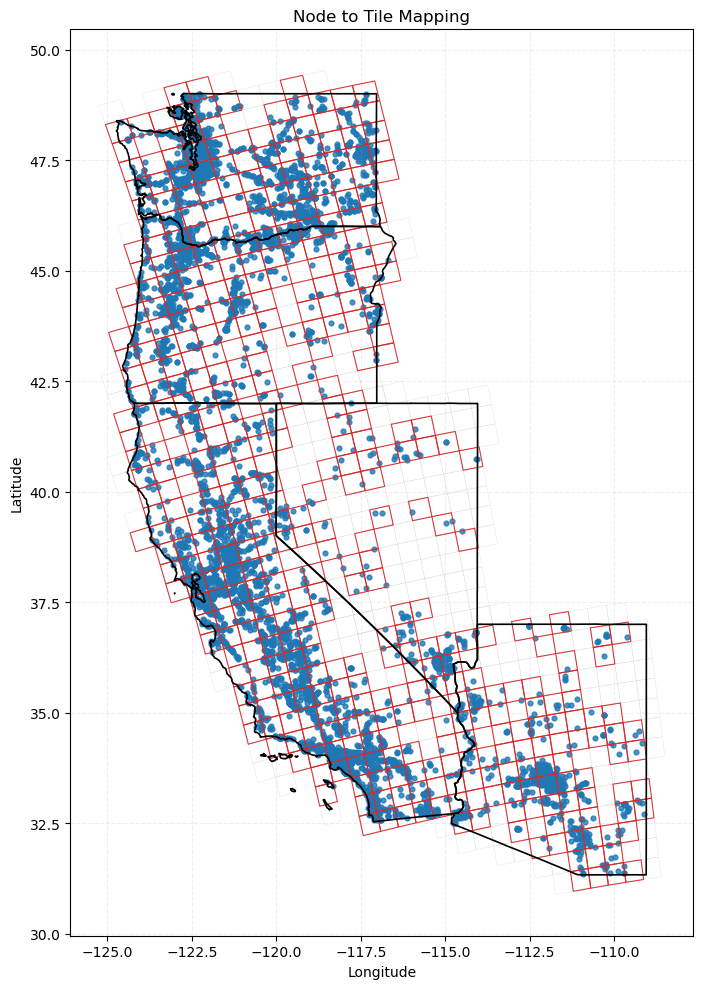

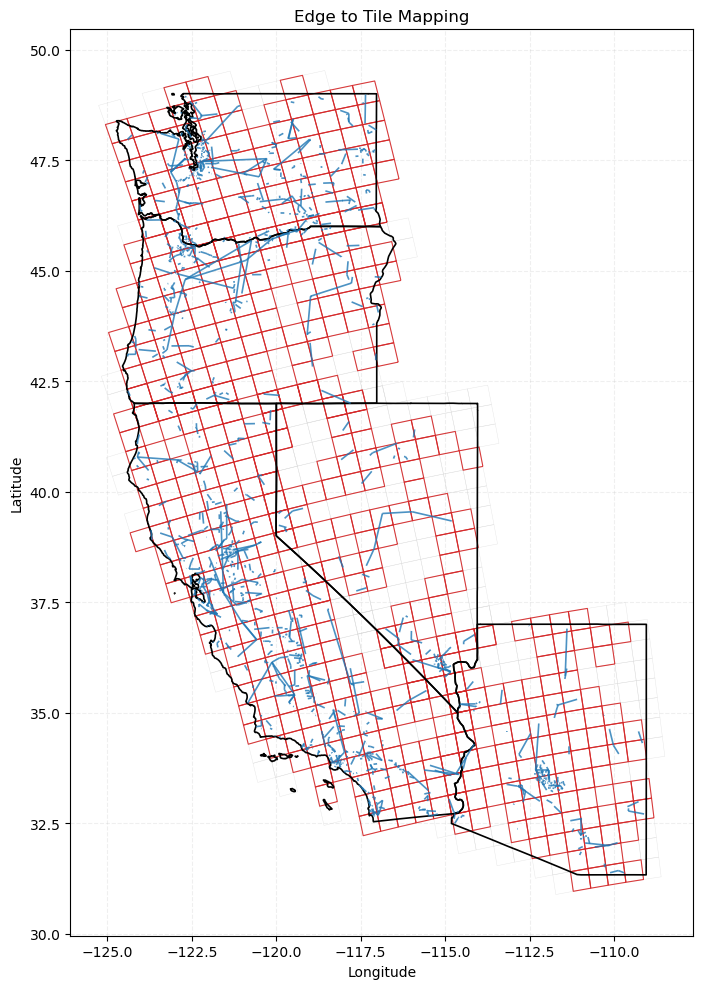

In [173]:
# ...existing code...

# 1) If any accidental tuple assignment happened earlier, unwrap it
if isinstance(tiles_gdf, tuple):
    tiles_gdf = tiles_gdf[0]

if isinstance(nodes_gdf, tuple):
    nodes_gdf = nodes_gdf[0]

if isinstance(edges_gdf, tuple):
    edges_gdf = edges_gdf[0]

# 2) Convert mapping dicts to DataFrames
node_to_tile_df = pd.DataFrame(
    [{"node_id": k, "tile_id": v} for k, v in node_to_tile.items()]
)

edge_to_tiles_df = pd.DataFrame(
    [(edge_id, tile_id) for edge_id, tile_list in edge_to_tiles.items() for tile_id in tile_list],
    columns=["edge_id", "tile_id"]
)

print(type(tiles_gdf), len(tiles_gdf))
print(type(node_to_tile_df), node_to_tile_df.shape)
print(type(edge_to_tiles_df), edge_to_tiles_df.shape)
# ...existing code...

# ...existing code...
node_audit = audit_element_to_tile_mapping(
    elements_gdf=nodes_gdf,
    mapping_df=node_to_tile_df,
    tiles_gdf=tiles_gdf,
    element_id_col="node_id",
    tile_id_col="tile_id",
    label="node",
)

edge_audit = audit_element_to_tile_mapping(
    elements_gdf=edges_gdf,
    mapping_df=edge_to_tiles_df,
    tiles_gdf=tiles_gdf,
    element_id_col="edge_id",
    tile_id_col="tile_id",
    label="edge",
)

plot_mapping_check(
    tiles_gdf=tiles_gdf,
    elements_gdf=nodes_gdf,
    mapping_df=node_to_tile_df,
    element_id_col="node_id",
    tile_id_col="tile_id",
    title="Node to Tile Mapping",
    aoi_gdf=gdf_aoi,
)

plot_mapping_check(
    tiles_gdf=tiles_gdf,
    elements_gdf=edges_gdf,
    mapping_df=edge_to_tiles_df,
    element_id_col="edge_id",
    tile_id_col="tile_id",
    title="Edge to Tile Mapping",
    aoi_gdf=gdf_aoi,
    sample_n=2000,
)
# ...existing code...

In [191]:

# Los Angeles (downtown) point
la_pt = gpd.GeoDataFrame(
    {"name": ["Los Angeles"]},
    geometry=[Point(-118.2437, 34.0522)],
    crs="EPSG:4326",
).to_crs(tiles_gdf.crs)

hit = gpd.sjoin(
    la_pt,
    tiles_gdf[["tile_id", "geometry"]],
    how="left",
    predicate="within",
).drop(columns=["index_right"], errors="ignore")

# Fallback to nearest tile if point lands exactly on boundary
if hit["tile_id"].isna().any():
    hit = gpd.sjoin_nearest(
        la_pt,
        tiles_gdf[["tile_id", "geometry"]],
        how="left",
        distance_col="dist_to_tile"
    ).drop(columns=["index_right"], errors="ignore")

print("LA tile_id:", hit.iloc[0]["tile_id"])
# ...existing code...

LA tile_id: T0000126


Tile: T0000126
Mapped nodes: 125
Mapped edges: 158


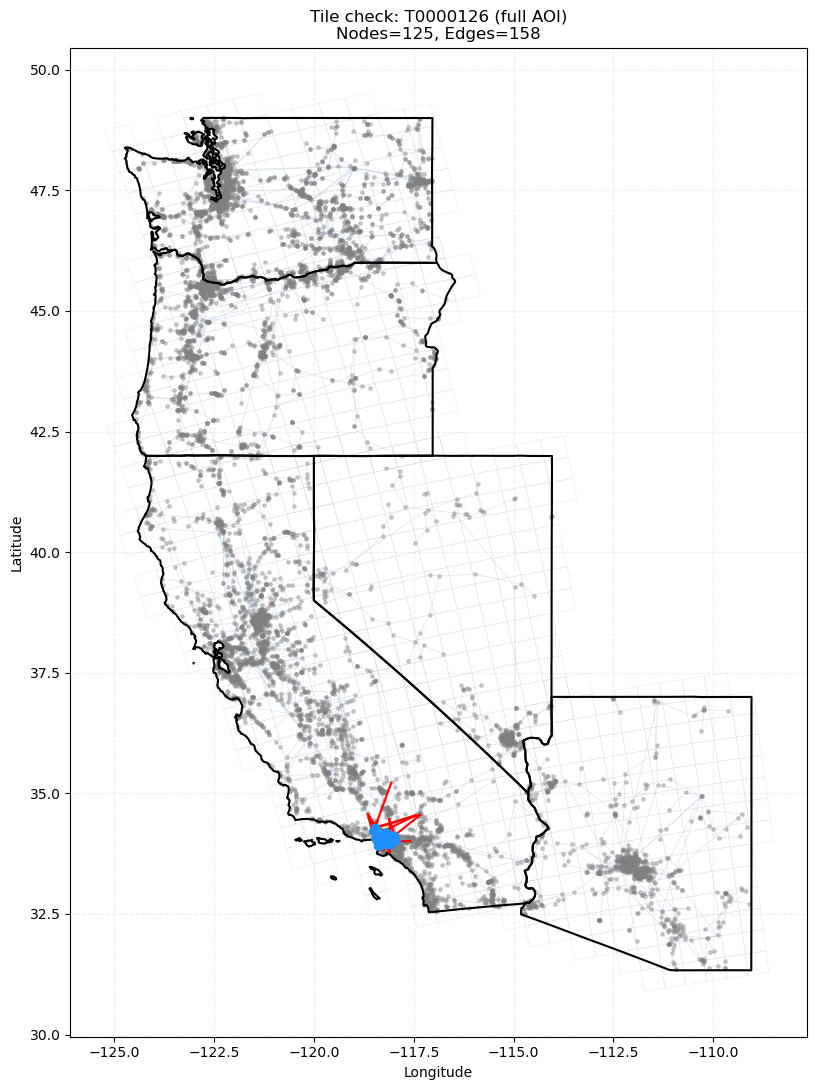

In [192]:

target_tile_id = "T0000126" #"T0000672"
plot_crs = "EPSG:4326"

# Normalize mapping inputs (DataFrame preferred; fallback to dicts)
if "node_to_tile_df" in globals():
    nmap = node_to_tile_df[["node_id", "tile_id"]].drop_duplicates().copy()
elif "node_to_tile" in globals():
    nmap = pd.DataFrame([{"node_id": k, "tile_id": v} for k, v in node_to_tile.items()])
else:
    raise ValueError("No node mapping found (node_to_tile_df or node_to_tile).")

if "edge_to_tiles_df" in globals():
    emap = edge_to_tiles_df[["edge_id", "tile_id"]].drop_duplicates().copy()
elif "edge_to_tiles" in globals():
    emap = pd.DataFrame(
        [(eid, tid) for eid, tids in edge_to_tiles.items() for tid in tids],
        columns=["edge_id", "tile_id"]
    )
else:
    raise ValueError("No edge mapping found (edge_to_tiles_df or edge_to_tiles).")

# Selected tile
tile_sel = tiles_gdf.loc[tiles_gdf["tile_id"] == target_tile_id].copy()
if tile_sel.empty:
    raise ValueError(f"Tile {target_tile_id} not found in tiles_gdf.")

# Elements mapped to selected tile
node_ids = nmap.loc[nmap["tile_id"] == target_tile_id, "node_id"].unique()
edge_ids = emap.loc[emap["tile_id"] == target_tile_id, "edge_id"].unique()

nodes_sel = nodes_gdf[nodes_gdf["node_id"].isin(node_ids)].copy()
edges_sel = edges_gdf[edges_gdf["edge_id"].isin(edge_ids)].copy()

print(f"Tile: {target_tile_id}")
print(f"Mapped nodes: {len(nodes_sel)}")
print(f"Mapped edges: {len(edges_sel)}")

# Plot on full AOI extent
aoi_p   = gdf_aoi.to_crs(plot_crs)
tiles_p = tiles_gdf.to_crs(plot_crs)
tile_p  = tile_sel.to_crs(plot_crs)
nodes_p = nodes_gdf.to_crs(plot_crs)
edges_p = edges_gdf.to_crs(plot_crs)
nodes_h = nodes_sel.to_crs(plot_crs)
edges_h = edges_sel.to_crs(plot_crs)

fig, ax = plt.subplots(figsize=(14, 11))

# Context layers (full AOI)
tiles_p.boundary.plot(ax=ax, color="lightgray", linewidth=0.25, alpha=0.7, zorder=1)
edges_p.plot(ax=ax, color="lightsteelblue", linewidth=0.5, alpha=0.45, zorder=2)
nodes_p.plot(ax=ax, color="gray", markersize=6, alpha=0.35, zorder=3)
aoi_p.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=4)

# Highlight selected tile + mapped elements
tile_p.plot(ax=ax, facecolor="gold", edgecolor="red", linewidth=2.0, alpha=0.35, zorder=5)
edges_h.plot(ax=ax, color="red", linewidth=1.6, alpha=0.95, zorder=6)
nodes_h.plot(ax=ax, color="dodgerblue", markersize=18, alpha=0.95, zorder=7)

ax.set_title(f"Tile check: {target_tile_id} (full AOI)\nNodes={len(nodes_sel)}, Edges={len(edges_sel)}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()
# ...existing code...

# Read in outage data


## Eagle-I

In [ ]:
directory = '/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/EAGLE-I/'
file = 'outage_data_2023.csv'

eaglei_data = pd.read_csv(os.path.join(directory,file))
eaglei_data.head()

eaglei_data['datetime'] = pd.to_datetime(eaglei_data['run_start_time'], errors='coerce')  # Handle any invalid dates

# Define start and end dates
start_date = '2023-03-26'
end_date = '2023-04-06'

# Filter rows that fall within the date range
eaglei_data = eaglei_data[(eaglei_data['datetime'] >= start_date) & (eaglei_data['datetime'] <= end_date)]




In [205]:
eaglei_data 

,fips_code,county,state,sum,run_start_time,datetime
5288230,1003,Baldwin,Alabama,6,2023-03-26 00:00:00,2023-03-26
5288231,1005,Barbour,Alabama,4,2023-03-26 00:00:00,2023-03-26
5288232,1007,Bibb,Alabama,4,2023-03-26 00:00:00,2023-03-26
5288233,1015,Calhoun,Alabama,4,2023-03-26 00:00:00,2023-03-26
5288234,1027,Clay,Alabama,4,2023-03-26 00:00:00,2023-03-26
...,...,...,...,...,...,...
6192667,55125,Vilas,Wisconsin,28,2023-04-06 00:00:00,2023-04-06
6192668,55129,Washburn,Wisconsin,48,2023-04-06 00:00:00,2023-04-06
6192669,55133,Waukesha,Wisconsin,20,2023-04-06 00:00:00,2023-04-06
6192670,55135,Waupaca,Wisconsin,3,2023-04-06 00:00:00,2023-04-06


## Whisker

In [201]:
whisker_outages_file = '/Users/ryanmc/Documents/NASA_JPL/Projects/NaturalHazards/NASA ROSES Disasters 2025-2027/data/Whisker_Labs_Data_March2026/2023-03-26 to 2023-04-09 Event/PowerOutages.json'

try:
    # Open the file in read mode and load its contents
    with open(whisker_outages_file, 'r', encoding='utf-8') as file:
        whisker_outages = json.load(file)

    # Pretty-print the Python object (which is usually a dictionary or list)
    # to the console in valid JSON format
    print(json.dumps(whisker_outages, indent=4, sort_keys=True))
    
except FileNotFoundError:
    print(f"Error: The file '{whisker_outages_file}' was not found.")
except json.JSONDecodeError as e:
    print(f"Error: Failed to decode JSON from the file. Details: {e}")
    
    

[
    {
        "AverageAmplitude": 0.0,
        "Location": {
            "Latitude": 41.436,
            "Longitude": -81.822
        },
        "Sensors": 4,
        "StartTime": "2023-03-26T00:15:27.094+00:00",
        "StartTimeLocal": "2023-03-25T20:15:27.094-04:00",
        "Type": "PowerOutage"
    },
    {
        "AverageAmplitude": 0.0,
        "Location": {
            "Latitude": 41.444,
            "Longitude": -81.782
        },
        "Sensors": 16,
        "StartTime": "2023-03-26T00:15:31.9+00:00",
        "StartTimeLocal": "2023-03-25T20:15:31.9-04:00",
        "Type": "PowerOutage"
    },
    {
        "AverageAmplitude": 0.0,
        "Location": {
            "Latitude": 39.996,
            "Longitude": -80.695
        },
        "Sensors": 5,
        "StartTime": "2023-03-26T00:16:53.111+00:00",
        "StartTimeLocal": "2023-03-25T20:16:53.111-04:00",
        "Type": "PowerOutage"
    },
    {
        "AverageAmplitude": 0.0,
        "Location": {
            "

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import plotly.graph_objects as go
import requests
from shapely.geometry import Point

# ----------------------------
# Time window (UTC)
# ----------------------------
t0 = pd.Timestamp("2023-03-31 00:00:00", tz="UTC")
t1 = pd.Timestamp("2023-04-02 00:00:00", tz="UTC")
time_index = pd.date_range(t0, t1, freq="1H") 

# ----------------------------
# Prep EAGLE-I
# ----------------------------
eg = eaglei_data.copy()

if "datetime" not in eg.columns:
    eg["datetime"] = pd.to_datetime(eg["run_start_time"], errors="coerce", utc=True)
else:
    eg["datetime"] = pd.to_datetime(eg["datetime"], errors="coerce", utc=True)

value_col = "sum" if "sum" in eg.columns else "customers_out"
if value_col not in eg.columns:
    raise KeyError("Could not find outage value column ('sum' or 'customers_out').")

def _norm_fips(x):
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s.zfill(5)

eg["fips_code"] = eg["fips_code"].map(_norm_fips)
eg[value_col] = pd.to_numeric(eg[value_col], errors="coerce").fillna(0)

# AOI state filter
aoi_states = set(gdf_aoi["name"].astype(str).str.upper().str.strip()) if "name" in gdf_aoi.columns else set()
if aoi_states and "state" in eg.columns:
    eg = eg[eg["state"].astype(str).str.upper().isin(aoi_states)].copy()

eg = eg[(eg["datetime"] >= t0) & (eg["datetime"] <= t1)].copy()
eg["time_hour"] = eg["datetime"].dt.floor("H")

eg_hourly = (
    eg.groupby(["time_hour", "fips_code"], as_index=False)[value_col]
      .sum()
)

# ----------------------------
# County GeoJSON
# ----------------------------
geojson_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
counties_geojson = requests.get(geojson_url, timeout=60).json()

# keep AOI states by FIPS prefix inferred from EAGLE-I filtered rows
aoi_statefp = set(eg["fips_code"].str[:2].dropna().unique())
aoi_county_ids = sorted([f["id"] for f in counties_geojson["features"] if f["id"][:2] in aoi_statefp])

# complete hourly matrix so slider is stable
eg_mat = (
    eg_hourly.pivot(index="time_hour", columns="fips_code", values=value_col)
    .reindex(index=time_index, columns=aoi_county_ids)
    .fillna(0)
)

# ----------------------------
# Prep Whisker outages
# ----------------------------
wr = whisker_outages["features"] if isinstance(whisker_outages, dict) and "features" in whisker_outages else whisker_outages
rows = []
for item in wr:
    try:
        rows.append({
            "lon": float(item["Location"]["Longitude"]),
            "lat": float(item["Location"]["Latitude"]),
            "Sensors": pd.to_numeric(item.get("Sensors", 0), errors="coerce"),
            "StartTime": pd.to_datetime(item.get("StartTime"), errors="coerce", utc=True),
        })
    except Exception:
        continue

wdf = pd.DataFrame(rows).dropna(subset=["lon", "lat", "StartTime"]).copy()
wdf = wdf[(wdf["StartTime"] >= t0) & (wdf["StartTime"] <= t1)].copy()

# spatial clip whisker points to AOI
w_gdf = gpd.GeoDataFrame(wdf, geometry=gpd.points_from_xy(wdf["lon"], wdf["lat"]), crs="EPSG:4326")
aoi_4326 = gdf_aoi.to_crs("EPSG:4326")
w_gdf = gpd.sjoin(w_gdf, aoi_4326[["geometry"]], how="inner", predicate="within").drop(columns=["index_right"], errors="ignore")
wdf = pd.DataFrame(w_gdf.drop(columns="geometry"))
wdf["time_hour"] = wdf["StartTime"].dt.floor("H")
wdf["Sensors"] = pd.to_numeric(wdf["Sensors"], errors="coerce").fillna(0)

# ----------------------------
# AOI boundary traces
# ----------------------------
boundary_traces = []
for geom in aoi_4326.geometry:
    polys = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
    for poly in polys:
        x, y = poly.exterior.xy
        boundary_traces.append(
            go.Scattergeo(
                lon=list(x),
                lat=list(y),
                mode="lines",
                line=dict(color="black", width=1.5),
                hoverinfo="skip",
                showlegend=False,
                name="AOI boundary",
            )
        )

# ----------------------------
# Build frames
# ----------------------------
first_t = time_index[0]
z0 = eg_mat.loc[first_t].values if first_t in eg_mat.index else np.zeros(len(aoi_county_ids))
w0 = wdf[wdf["time_hour"] == first_t]

base_choro = go.Choropleth(
    geojson=counties_geojson,
    locations=aoi_county_ids,
    z=z0,
    zmin=0,
    zmax=max(1, float(np.nanmax(eg_mat.values))),
    colorscale="YlOrRd",
    marker_line_width=0.2,
    marker_line_color="white",
    colorbar=dict(title=value_col),
    name="EAGLE-I outages",
)

base_scatter = go.Scattergeo(
    lon=w0["lon"],
    lat=w0["lat"],
    mode="markers",
    marker=dict(
        size=np.clip(w0["Sensors"], 3, 18),
        color="deepskyblue",
        opacity=0.75,
        line=dict(width=0.5, color="navy"),
    ),
    text=[f"Sensors: {int(s)}<br>{t}" for s, t in zip(w0["Sensors"], w0["StartTime"])],
    hoverinfo="text",
    name="Whisker outages",
)

frames = []
for t in time_index:
    zt = eg_mat.loc[t].values if t in eg_mat.index else np.zeros(len(aoi_county_ids))
    wt = wdf[wdf["time_hour"] == t]

    frames.append(
        go.Frame(
            name=str(t),
            data=[
                go.Choropleth(
                    geojson=counties_geojson,
                    locations=aoi_county_ids,
                    z=zt,
                    zmin=0,
                    zmax=max(1, float(np.nanmax(eg_mat.values))),
                    colorscale="YlOrRd",
                    marker_line_width=0.2,
                    marker_line_color="white",
                    colorbar=dict(title=value_col),
                ),
                go.Scattergeo(
                    lon=wt["lon"],
                    lat=wt["lat"],
                    mode="markers",
                    marker=dict(
                        size=np.clip(wt["Sensors"], 3, 18),
                        color="deepskyblue",
                        opacity=0.75,
                        line=dict(width=0.5, color="navy"),
                    ),
                    text=[f"Sensors: {int(s)}<br>{ts}" for s, ts in zip(wt["Sensors"], wt["StartTime"])],
                    hoverinfo="text",
                ),
            ],
            traces=[0, 1],
        )
    )

fig = go.Figure(data=[base_choro, base_scatter] + boundary_traces, frames=frames)

fig.update_layout(
    title="EAGLE-I county outages + Whisker outage points (Sensors-sized), UTC hourly",
    geo=dict(scope="usa", projection_type="albers usa", showland=True, landcolor="rgb(245,245,245)"),
    height=800,
    width=1200,
    template="plotly_white",
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "Time (UTC): "},
        "pad": {"t": 40},
        "steps": [
            {"label": pd.Timestamp(t).strftime("%m-%d %H:%M"), "method": "animate",
             "args": [[str(t)], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}]}
            for t in time_index
        ],
    }],
    updatemenus=[{
        "type": "buttons",
        "showactive": False,
        "x": 1.02, "y": 1.08,
        "buttons": [
            {"label": "Play", "method": "animate",
             "args": [None, {"frame": {"duration": 350, "redraw": True}, "fromcurrent": True}]},
            {"label": "Pause", "method": "animate",
             "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}]},
        ],
    }],
)

fig.show()


/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_12142/1771835310.py:13: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_12142/1771835310.py:44: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/g_/2j33jfhn72j448cr82hzgr0c0002d4/T/ipykernel_12142/1771835310.py:92: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



# Calculate stresses on the grid components

# Apply fragility analyses

# Explore the event outage expectation

Some things we will need
- line parameters (somehow defined; what information do we have?)
     - line capacity 
- power distribution (what information do we have?)
    - (negative power) the load network
        - what can we assume? household-level (cotality)? only large-loads? 
    - (positive power) the generation network (eGRID or de-anonymized GADS)
        - how could GADS data be used for this? 


In [ ]:
# Read in outage information for validation

# Below is exploratory analysis

# get outage data for the AoI

In [ ]:
# Load EAGLE-I outage data for 2024
 
# Path to EAGLE-I data
eaglei_directory = '/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/EAGLE-I/'
eaglei_file = 'eaglei_outages_2024.csv'

print(f"Loading EAGLE-I data from {os.path.join(eaglei_directory, eaglei_file)}...")
outage_data = pd.read_csv(os.path.join(eaglei_directory, eaglei_file))

# Convert timestamp to datetime
outage_data['datetime'] = pd.to_datetime(outage_data['run_start_time'])

# Filter to study period (March 31 - April 4, 2023)
study_start = '2024-02-01'
study_end = '2024-03-01'
outage_filtered = outage_data[(outage_data['datetime'] >= study_start) & 
                               (outage_data['datetime'] <= study_end)].copy()

print(f"\nOriginal EAGLE-I data shape: {outage_data.shape}")
print(f"Filtered to study period: {outage_filtered.shape}")
print(f"\nColumns: {list(outage_filtered.columns)}")
print(f"\nDate range: {outage_filtered['datetime'].min()} to {outage_filtered['datetime'].max()}")
print(f"Temporal resolution: ~{(outage_filtered['datetime'].diff().max())}")
print(f"\nSample data:")
print(outage_filtered.head())

In [ ]:
# Resample to hourly resolution

print("\nResampling outage data to hourly resolution...")
# Group by county and hour, sum customers without power (include state and county for later use)
outage_filtered['datetime_hour'] = outage_filtered['datetime'].dt.floor('H')
outage_hourly = outage_filtered.groupby(['fips_code', 'state', 'county', 'datetime_hour'])['customers_out'].sum().reset_index()
outage_hourly.rename(columns={'datetime_hour': 'datetime'}, inplace=True)
print(f"outage_hourly shape: {outage_hourly.shape}")
print(f"\nSample hourly outage data:")
print(outage_hourly.head())

In [ ]:

# Load the US County GeoJSON file
counties_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
print(f"Downloading county geometries from {counties_url}...")
response = requests.get(counties_url)
counties_geojson = response.json()


# Convert to GeoDataFrame
counties_records = []
for feature in counties_geojson['features']:
    geom = shape(feature['geometry'])
    fips = feature['id']
    counties_records.append({
        'fips_code': fips,
        'geometry': geom
    })

counties_gdf = gpd.GeoDataFrame(counties_records, crs='EPSG:4326')
print(f"\nCounties GeoDataFrame shape: {counties_gdf.shape}")
print(f"CRS: {counties_gdf.crs}")
print(counties_gdf.head())

In [ ]:
# Ensure EAGLE-I hourly data has FIPS codes formatted correctly (5-digit string with leading zeros)
outage_hourly['fips_code'] = outage_hourly['fips_code'].astype(str).str.zfill(5)

# Merge hourly outage data with county geometries
outage_with_geom = counties_gdf.merge(outage_hourly, on='fips_code', how='inner')
outage_with_geom = gpd.GeoDataFrame(outage_with_geom, crs='EPSG:4326')

print(f"\nHourly outage data merged with county geometries: {outage_with_geom.shape}")
print(f"Records with geometry: {outage_with_geom['geometry'].notna().sum()}")
print(f"\nSample merged data:")
print(outage_with_geom[['fips_code', 'state', 'county', 'datetime', 'customers_out', 'geometry']].head())

# Create Animated Movie: Outages Over Time
Chloropleth map (bottom) with aggregated time series (top) showing customers out by county

In [ ]:
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

# Get states in the AOI (normalize to uppercase)
states_in_aoi_raw = gdf_aoi['name'].unique() if 'name' in gdf_aoi.columns else gdf_aoi.index.unique()
states_in_aoi = sorted([s.upper() for s in states_in_aoi_raw])

# Filter outage data to only AOI (normalize state to uppercase for matching)
outage_in_aoi = outage_with_geom[outage_with_geom['state'].str.upper().isin(states_in_aoi)].copy()

# Prepare time series data for the top plot (filtered to AOI states)
# Aggregate by state and datetime (normalize state to uppercase)
outage_in_aoi['state_normalized'] = outage_in_aoi['state'].str.upper()
ts_by_state = outage_in_aoi.groupby(['state_normalized', 'datetime'])['customers_out'].sum().reset_index()
ts_by_state.rename(columns={'state_normalized': 'state'}, inplace=True)
ts_total = outage_in_aoi.groupby('datetime')['customers_out'].sum().reset_index()

# Sort by datetime
ts_by_state = ts_by_state.sort_values('datetime')
ts_total = ts_total.sort_values('datetime')

# Get unique times and states (only those in AOI)
unique_times = sorted(outage_in_aoi['datetime'].unique())
unique_states = sorted(ts_by_state['state'].unique())

# Get AOI bounds for zooming
aoi_bounds = gdf_aoi.total_bounds  # [minx, miny, maxx, maxy]

print(f"Total number of timesteps: {len(unique_times)}")
print(f"Date range: {unique_times[0]} to {unique_times[-1]}")
print(f"States in AOI: {unique_states}")
print(f"AOI bounds: {aoi_bounds}")


In [ ]:
# Test first frame before creating full animation
# Set up color mapping for states
state_colors = {state: cm.get_cmap('tab10')(i) for i, state in enumerate(unique_states)}

# Prepare data for chloropleth (only AOI counties)
outage_anim_data = outage_in_aoi.copy()

# Create normalization for the chloropleth
vmin = outage_anim_data['customers_out'].min()
vmax = outage_anim_data['customers_out'].max()
norm = Normalize(vmin=vmin, vmax=vmax)

def animate(frame_idx, save_frame=False, frame_path=None):
    """Update function for animation"""
    # Get current time
    current_time = unique_times[frame_idx]
    
    # Create figure with 2 subplots for each frame
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.3)
    ax_ts = fig.add_subplot(gs[0])
    ax_map = fig.add_subplot(gs[1])
    
    # === TOP PLOT: Time Series (only AOI states) ===
    # Plot total customers out (black line)
    ax_ts.plot(ts_total['datetime'], ts_total['customers_out'], 
              color='black', linewidth=2.5, label='Total (AOI)', zorder=2)
    
    # Plot each state's time series
    for state in unique_states:
        state_data = ts_by_state[ts_by_state['state'] == state]
        ax_ts.plot(state_data['datetime'], state_data['customers_out'], 
                  color=state_colors[state], linewidth=1.5, label=state, alpha=0.7)
    
    # Add vertical line at current time
    ax_ts.axvline(current_time, color='red', linewidth=2.5, linestyle='--', 
                 label=f'Current: {current_time.strftime("%Y-%m-%d %H:%M")}', zorder=3)
    
    ax_ts.set_xlabel('Date/Time', fontsize=11)
    ax_ts.set_ylabel('Customers Out', fontsize=11)
    ax_ts.set_title('Aggregated Outages Over Time (AOI States)', fontsize=12, fontweight='bold')
    ax_ts.legend(loc='upper left', fontsize=9, ncol=2)
    ax_ts.grid(True, alpha=0.3)
    ax_ts.set_xlim(ts_total['datetime'].min(), ts_total['datetime'].max())
    
    # === BOTTOM PLOT: Chloropleth Map (zoomed to AOI) ===
    # Get data for current timestep
    current_data = outage_anim_data[outage_anim_data['datetime'] == current_time].copy()
    
    # Plot base counties (only those in AOI)
    counties_in_aoi = counties_gdf[counties_gdf.geometry.bounds.apply(
        lambda row: (row.minx >= aoi_bounds[0] and row.miny >= aoi_bounds[1] and 
                     row.maxx <= aoi_bounds[2] and row.maxy <= aoi_bounds[3]), axis=1)]
    counties_in_aoi.plot(ax=ax_map, color='lightgray', edgecolor='white', linewidth=0.5)
    
    # Plot counties with outage data
    if len(current_data) > 0:
        current_data.plot(ax=ax_map, column='customers_out', cmap='YlOrRd', 
                         edgecolor='black', linewidth=0.3, norm=norm, 
                         legend=False, alpha=0.8)
    
    # Overlay state boundaries
    gdf_aoi.plot(ax=ax_map, edgecolor='darkblue', facecolor='none', linewidth=2, alpha=0.7)
    
    # Add colorbar
    sm = ScalarMappable(cmap='YlOrRd', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax_map, orientation='vertical', pad=0.02)
    cbar.set_label('Customers Out', fontsize=11)
    
    ax_map.set_xlabel('Longitude', fontsize=11)
    ax_map.set_ylabel('Latitude', fontsize=11)
    ax_map.set_title(f'Outages by County: {current_time.strftime("%Y-%m-%d %H:%M UTC")}', 
                    fontsize=12, fontweight='bold')
    ax_map.grid(True, alpha=0.2)
    
    # Zoom to AOI
    ax_map.set_xlim(aoi_bounds[0], aoi_bounds[2])
    ax_map.set_ylim(aoi_bounds[1], aoi_bounds[3])
    
    # Save frame if requested
    if save_frame and frame_path:
        plt.tight_layout()
        fig.savefig(frame_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
    
    return fig

# Test the first frame
print("Testing first frame...")
test_fig = animate(100)
plt.tight_layout()
plt.show()

In [ ]:
# Create full animation (run after confirming first frame looks good)
print("Creating full animation...")
frame_indices = list(range(0, len(unique_times), 1))  # Change step to reduce frames if needed

dir_frames = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_frames/CA_aoi_2024/"
if not os.path.exists(dir_frames):
    os.makedirs(dir_frames)
    print('making directory {}'.format(dir_frames))
    
dir_movie = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_movies/"

# Create output directory if it doesn't exist
os.makedirs(dir_frames, exist_ok=True)

# Save individual frames for later exploration
print(f"Saving {len(frame_indices)} individual frames...")
for idx in frame_indices:
    frame_filename = os.path.join(dir_frames, f"frame_{idx:05d}.png")
    animate(idx, save_frame=True, frame_path=frame_filename)
    if (idx + 1) % 50 == 0:
        print(f"  Saved {idx + 1}/{len(frame_indices)} frames")
print("Individual frames saved!")

print("\nTo create MP4 from frames, run:")
print(f"ffmpeg -framerate 4 -i {dir_frames}frame_%05d.png -c:v libx264 -pix_fmt yuv420p -b:v 1800k {dir_movie}outages_animation.mp4")